
# Geolife dataset analysis
## Part 1: Analysis of small dataset
This notebook performs an analysis of the Geolife dataset, specifically:
- Number of trajectories for each means of transport
- Typical velocities for each means of transport
- Typical interval (time and space) between each point (based on the means of transport)
- Typical hours of the day when each means of transport is used
## Part 2: Analysis of whole dataset
This section also performs an analysis on the Geolife dataset as a whole. The analysis includes the following tasks:

1. Counting the number of users with and without means of transport.
2. Determining the number of locations associated with means of transport.
3. Analyzing the distribution of records per means of transport, including visualizing this information through plotting.
4. Computing and summarizing the statistics from the above tasks for the entire dataset.

The goal is to provide insights into the dataset's structure and the distribution of transportation-related data.
## Part 3: Transport-based Pattern & User Behavior Analysis

This section continues the Geolife dataset analysis by focusing on user behavior and identifying location patterns based on the means of transport, with an emphasis on privacy risks. This part serves as a bridge between data exploration and the development of a privacy-preserving system.

- Group data by transport mode (not user) to reduce computation.
- Compute statistics: velocity, distance, time intervals, active hours.
- Plot trajectories on maps to detect transport lines.
- Analyze a user with multi-modal transport usage for routine patterns.
- Assess privacy risks from inferred patterns.

In [1]:
# contains multiple constant variables that result in a less verbose coding
import privkit as pk
import pandas as pd
import numpy as np
from datetime import datetime
from geopy.distance import geodesic
from privkit.utils import constants
import matplotlib.pyplot as plt
import seaborn as sns
from privkit.utils import (
    geo_utils,
)
from IPython.display import display

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2025-07-02 23:02:15.387065: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751490135.448324  146867 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751490135.468507  146867 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751490135.595104  146867 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751490135.595130  146867 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751490135.595132  146867 computation_placer.cc:177] computation placer alr

In [4]:
# loading geolife dataset
dataset = pk.datasets.GeolifeDataset()
# Loading the dataset 
dataset.load_dataset()
# Extracting the location data
location_data = dataset.data

Loading the geolife dataset
Dataset loaded from ./input/data/geolife.pkl


In [2]:
# Counting the number of users with and without means of transport
all_users = location_data.data['uid'].nunique()  # Correctly calculate the total number of unique users
users_with_transport = location_data.data[location_data.data['label'].notnull()]['uid'].nunique()  # Count users with transport
users_without_transport = all_users - users_with_transport  # Calculate users without transport

print(f"Total number of users: {all_users}")
print(f"Users with means of transport: {users_with_transport}")
print(f"Users without means of transport: {users_without_transport}")

NameError: name 'location_data' is not defined

In [5]:
# Sorting the user having means of transport (labels)
location_data.data = location_data.data[location_data.data['label'].notnull()]
# location_data.data = location_data.data[location_data.data['uid'] == 163]
# location_data.data = location_data.data[location_data.data['label'].notnull()]
# location_data.data = location_data.data[:5]  # To limit the number of records

# Task 2: Limiting the number of records for each user for testing purposes
location_data.data = location_data.data.groupby('uid').head(10)
# Printing the first few rows of the dataset
print("Location data sample:")
# prints a sample of the location data
display(location_data.data)

Location data sample:


,datetime,lat,lon,alt,tid,uid,label,original_lat,original_lon
0,2007-05-13 08:35:06,40.073750,116.318133,150.918635,2,115,car,40.073750,116.318133
1,2007-05-13 08:35:15,40.074167,116.317950,150.918635,2,115,car,40.074167,116.317950
2,2007-05-13 08:35:22,40.074433,116.317817,150.918635,2,115,car,40.074433,116.317817
3,2007-05-13 08:36:07,40.074617,116.317733,150.918635,2,115,car,40.074617,116.317733
4,2007-05-13 08:36:19,40.074967,116.317583,203.412073,2,115,car,40.074967,116.317583
...,...,...,...,...,...,...,...,...,...
5,2007-10-08 23:18:16,40.003767,116.461700,111.548556,1,106,car,40.003767,116.461700
6,2007-10-08 23:18:42,40.005900,116.461583,104.986877,1,106,car,40.005900,116.461583
7,2007-10-08 23:19:02,40.006233,116.461650,108.267717,1,106,car,40.006233,116.461650
8,2007-10-08 23:19:18,40.007017,116.461617,101.706037,1,106,car,40.007017,116.461617


In [8]:
# Sorting the data by user ID and datetime
location_data.data = location_data.data.sort_values(by=['uid', 'datetime'])

# Calculate previous coordinates and timestamps
location_data.data['prev_lat'] = location_data.data.groupby('uid')['lat'].shift(1)
location_data.data['prev_lon'] = location_data.data.groupby('uid')['lon'].shift(1)
location_data.data['prev_time'] = location_data.data.groupby('uid')['datetime'].shift(1)

# Compute distance in meters between consecutive points
location_data.data['distance'] = location_data.data.apply(
    lambda row: geodesic((row['lat'], row['lon']), (row['prev_lat'], row['prev_lon'])).meters
    if pd.notnull(row['prev_lat']) else 0, axis=1)

# Compute duration in seconds between timestamps
location_data.data['duration'] = (
    location_data.data['datetime'] - location_data.data['prev_time']
).dt.total_seconds().fillna(0)

# Compute velocity in m/s, avoiding division by zero
location_data.data['velocity'] = location_data.data['distance'] / \
    location_data.data['duration'].replace(0, np.nan)
location_data.data['velocity'] = location_data.data['velocity'].fillna(0)

# Drop rows without transport mode labels
location_data.data = location_data.data.dropna(subset=['label'])


: 

In [8]:
# Count number of trajectory points per transport mode
print("Number of trajectory points for each means of transport:")
means_of_transport = location_data.data['label'].value_counts()
display(means_of_transport)

# Compute average velocity per transport mode
print("\nTypical velocities for each means of transport:")
typical_velocities = location_data.data.groupby('label')['velocity'].mean().to_dict()
display(pd.DataFrame.from_dict(typical_velocities, orient='index', columns=['Velocity (m/s)']))

# Compute average distance per segment per transport mode
print("\nTypical distances for each means of transport:")
typical_distances = location_data.data.groupby('label')['distance'].mean().to_dict()
display(pd.DataFrame.from_dict(typical_distances, orient='index', columns=['Distance (m)']))

# Compute average duration per segment per transport mode
print("\nTypical durations for each means of transport:")
typical_durations = location_data.data.groupby('label')['duration'].mean().to_dict()
display(pd.DataFrame.from_dict(typical_durations, orient='index', columns=['Duration (seconds)']))

# Compute most typical hours of usage per transport mode
location_data.data['hour'] = location_data.data['datetime'].dt.hour
typical_hours = location_data.data.groupby('label')['hour'].apply(lambda x: x.mode().tolist()).to_dict()

print("\nTypical hours of the day when each means of transport is used:")
display(pd.DataFrame.from_dict(typical_hours, orient='index', columns=['Typical Hours']))


Number of trajectory points for each means of transport:


label
walk          1585401
bus           1276632
bike           948061
train          560979
car            512807
subway         286168
taxi           242018
airplane         9183
boat             3559
run              1971
motorcycle        338
Name: count, dtype: int64


Typical velocities for each means of transport:


KeyError: 'Column not found: velocity'

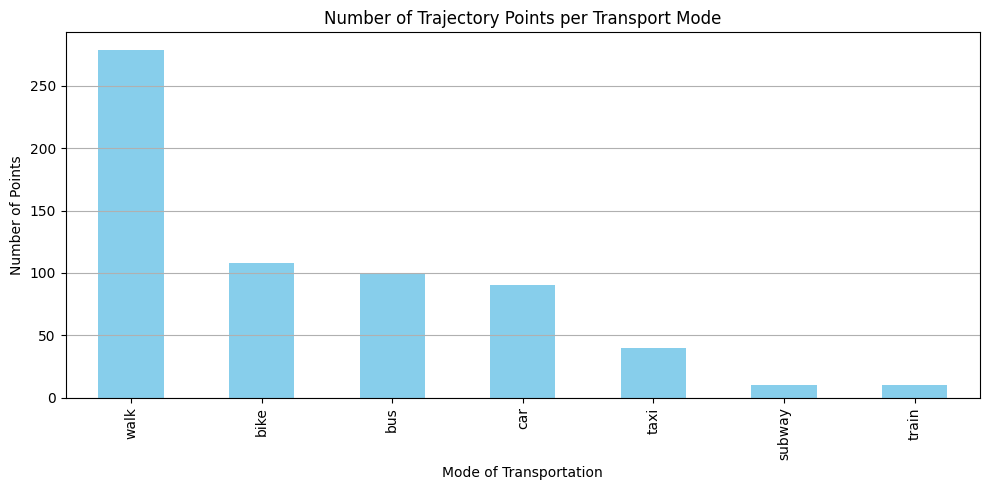

In [6]:
# Analyzing the distribution of records per means of transport
means_of_transport.plot(kind='bar', figsize=(10, 5), color='skyblue')
plt.title("Number of Trajectory Points per Transport Mode")
plt.xlabel("Mode of Transportation")
plt.ylabel("Number of Points")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


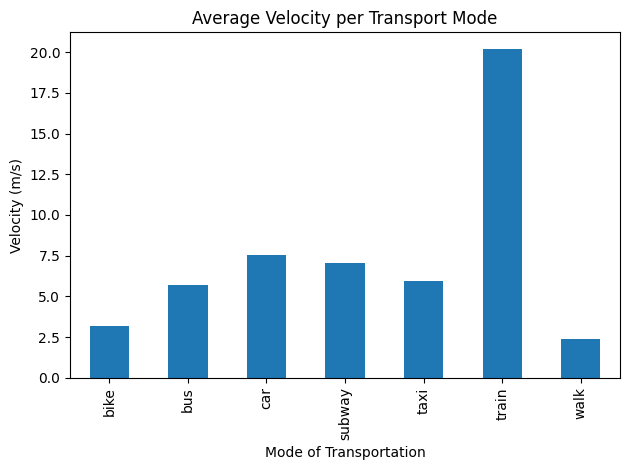

In [7]:
# Analyzing the average velocity per means of transport
plt.figure()
pd.Series(typical_velocities).plot(kind='bar')
plt.title("Average Velocity per Transport Mode")
plt.xlabel("Mode of Transportation")
plt.ylabel("Velocity (m/s)")
plt.tight_layout()
plt.show()

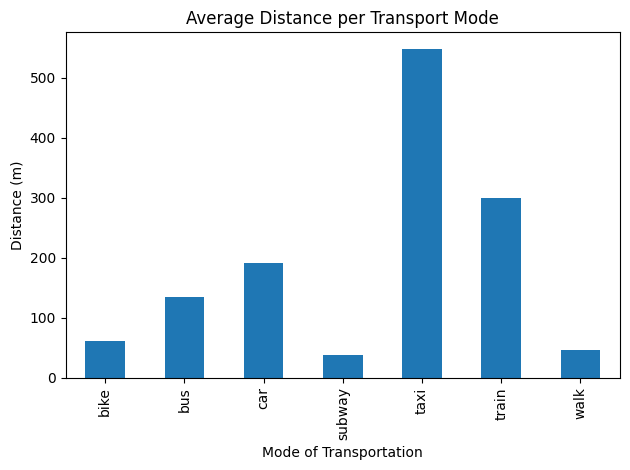

In [ ]:
# Analyzing the average disance per means of transport
plt.figure()
pd.Series(typical_distances).plot(kind='bar')
plt.title("Average Distance per Transport Mode")
plt.xlabel("Mode of Transportation")
plt.ylabel("Distance (m)")
plt.tight_layout()
plt.show()

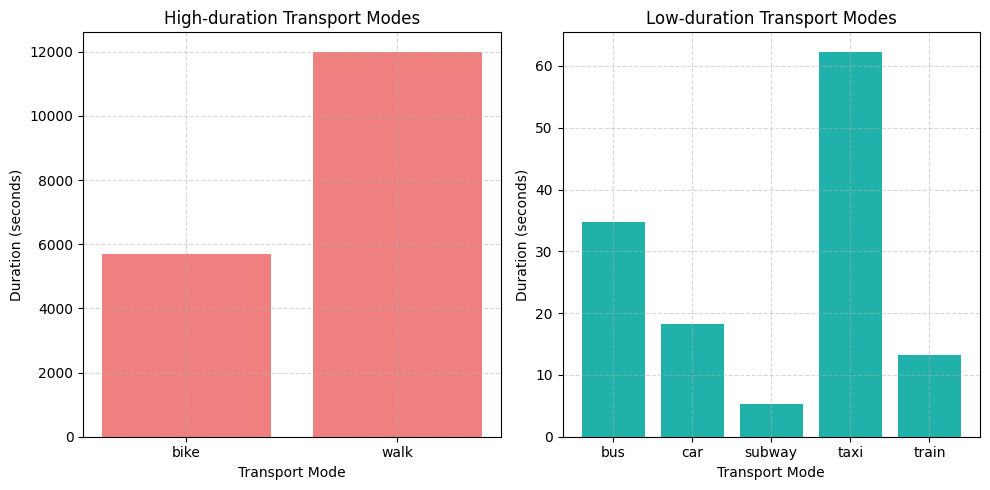

In [33]:
# Analyzing the average duration per means of transport
duration_series = pd.Series(typical_durations)

# Grouping transport modes by duration scale
high_duration = {k: v for k, v in typical_durations.items() if v > 1000}
low_duration = {k: v for k, v in typical_durations.items() if v <= 1000}

# Define a constant for the label "Transport Mode"
TRANSPORT_MODE_LABEL = "Transport Mode"

# Create two subplots side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot high-duration transport modes (e.g., walk, bike)
axs[0].bar(high_duration.keys(), high_duration.values(), color='lightcoral')
axs[0].set_title("High-duration Transport Modes")
axs[0].set_xlabel(TRANSPORT_MODE_LABEL)
axs[0].set_ylabel("Duration (seconds)")
axs[0].grid(True, linestyle='--', alpha=0.5)

# Plot low-duration transport modes (e.g., subway, taxi)
axs[1].bar(low_duration.keys(), low_duration.values(), color='lightseagreen')
axs[1].set_title("Low-duration Transport Modes")
axs[1].set_xlabel(TRANSPORT_MODE_LABEL)
axs[1].set_ylabel("Duration (seconds)")
axs[1].grid(True, linestyle='--', alpha=0.5)

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

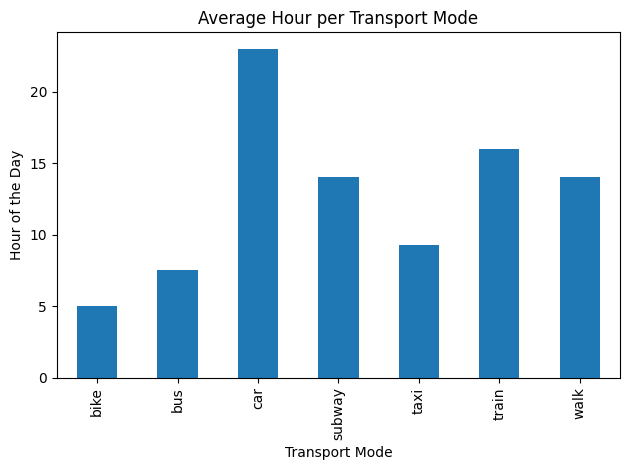

In [12]:
# Analyzing the average hour per means of transport
average_hours = {k: np.mean(v) for k, v in typical_hours.items()}

plt.figure()
pd.Series(average_hours).plot(kind='bar')
plt.title("Average Hour per Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Hour of the Day")
plt.tight_layout()
plt.show()

In [9]:
# Compute the distance for each group
def compute_dist_for_group(grp):
    lats = grp['lat'].tolist()
    lons = grp['lon'].tolist()
    if len(lats) < 2:
        return 0
    return geo_utils.compute_trace_distance(lats, lons)


In [10]:
# Task 3: Filter dataset with non-null means of transport
df = dataset.data.data.copy()
df = df[df['label'].notnull()]
# # Limit the records for each user for testing purposes
# df = df.groupby('uid').head(100)

# Grouping data by user and trajectory
grouped_data = dataset.get_trajectories()
# Calculating distance, duration, and velocity for each trajectory 
df['duration'] = (
    df
    .groupby(['uid','tid','label'])['datetime']
    .transform(lambda x: (x.max() - x.min()).total_seconds())
)

distance_per_group = df.groupby(['uid','tid','label']).apply(compute_dist_for_group)
df['distance'] = df.set_index(['uid','tid','label']).index.map(distance_per_group)



df['velocity'] = df.apply(
    lambda row: row['distance'] / row['duration'] if row['duration'] > 0 else 0,
    axis=1
)

# Grouping the dataset by transport mode and calculating statistics 
user_stats = df.groupby(['uid', 'label']).agg({
    'distance': ['mean', 'max', 'std'],
    'duration': ['mean', 'max', 'std'],
    'velocity': ['mean', 'max', 'std']
}).reset_index()

transport_stats = df.groupby('label').agg({
    'distance': ['mean', 'max', 'std'],
    'duration': ['mean', 'max', 'std'],
    'velocity': ['mean', 'max', 'std']
}).reset_index()

# Renaming the columns for clarity
transport_stats.columns = ['Transport_Mode', 'Dist_Mean', 'Dist_Max', 'Dist_Std',
                           'Dur_Mean', 'Dur_Max', 'Dur_Std',
                           'Vel_Mean', 'Vel_Max', 'Vel_Std']

# Printing the dataset with calculated fields
print("\nDataset with calculated fields:")
display(df[['uid', 'datetime', 'lat', 'lon', 'label', 'distance', 'duration', 'velocity']])

# Printing the statistics grouped by transport mode
print("\n📊 Statistics grouped by Transport Mode:")
display(transport_stats)


Dataset with calculated fields:


,uid,datetime,lat,lon,label,distance,duration,velocity
0,115,2007-05-13 08:35:06,40.073750,116.318133,car,38851.901271,2981.0,13.033177
1,115,2007-05-13 08:35:15,40.074167,116.317950,car,38851.901271,2981.0,13.033177
2,115,2007-05-13 08:35:22,40.074433,116.317817,car,38851.901271,2981.0,13.033177
3,115,2007-05-13 08:36:07,40.074617,116.317733,car,38851.901271,2981.0,13.033177
4,115,2007-05-13 08:36:19,40.074967,116.317583,car,38851.901271,2981.0,13.033177
...,...,...,...,...,...,...,...,...
747,106,2007-10-08 15:04:48,39.998200,116.455200,car,246450.319012,47348.0,5.205084
748,106,2007-10-08 15:04:58,39.998383,116.454983,car,246450.319012,47348.0,5.205084
749,106,2007-10-08 15:05:11,39.998350,116.454500,car,246450.319012,47348.0,5.205084
750,106,2007-10-08 15:05:26,39.998117,116.454717,car,246450.319012,47348.0,5.205084



📊 Statistics grouped by Transport Mode:


,Transport_Mode,Dist_Mean,Dist_Max,Dist_Std,Dur_Mean,Dur_Max,Dur_Std,Vel_Mean,Vel_Max,Vel_Std
0,airplane,2.040980e+06,4.389228e+06,1.316292e+06,10733.321137,19899.0,5244.149443,176.351403,233.357128,44.105993
1,bike,1.088121e+04,1.755433e+05,1.309205e+04,11615.255470,96483.0,14945.403069,2.399149,22.421188,1.903374
2,boat,2.937064e+04,6.588358e+04,3.099858e+04,4025.075864,7856.0,816.630645,7.242095,15.588943,7.298417
3,bus,4.884980e+04,1.631126e+06,1.253341e+05,15462.939911,118987.0,16900.211067,4.213815,64.463809,4.689711
4,car,8.016907e+04,1.432285e+06,1.116841e+05,9867.658033,58688.0,10465.504733,9.094348,35.602412,5.480341
5,motorcycle,2.145384e+03,2.145384e+03,0.000000e+00,336.000000,336.0,0.000000,6.385071,6.385071,0.000000
6,run,2.404285e+03,2.765142e+03,5.968987e+02,8309.824455,11418.0,4898.445059,0.905363,3.141686,1.094508
7,subway,2.798840e+04,2.105867e+05,2.934767e+04,6573.475273,53382.0,9844.130889,8.539218,31.160029,4.896750
8,taxi,5.732004e+04,1.183218e+06,1.443115e+05,8799.602806,70052.0,10796.540076,8.469412,47.691170,7.171037
9,train,8.815651e+05,1.956371e+06,5.656217e+05,45778.419196,86398.0,29604.567857,22.317839,65.522584,10.938182


In [50]:
user_stats = df.groupby(['uid', 'label']).agg({
    'distance': ['mean', 'max', 'std'],
    'duration': ['mean', 'max', 'std'],
    'velocity': ['mean', 'max', 'std']
}).reset_index()

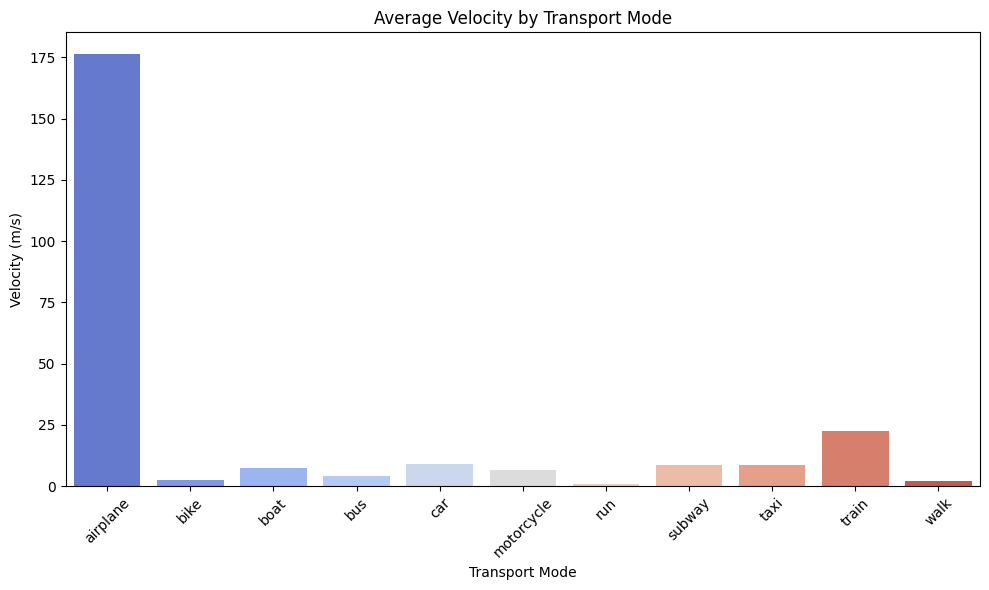

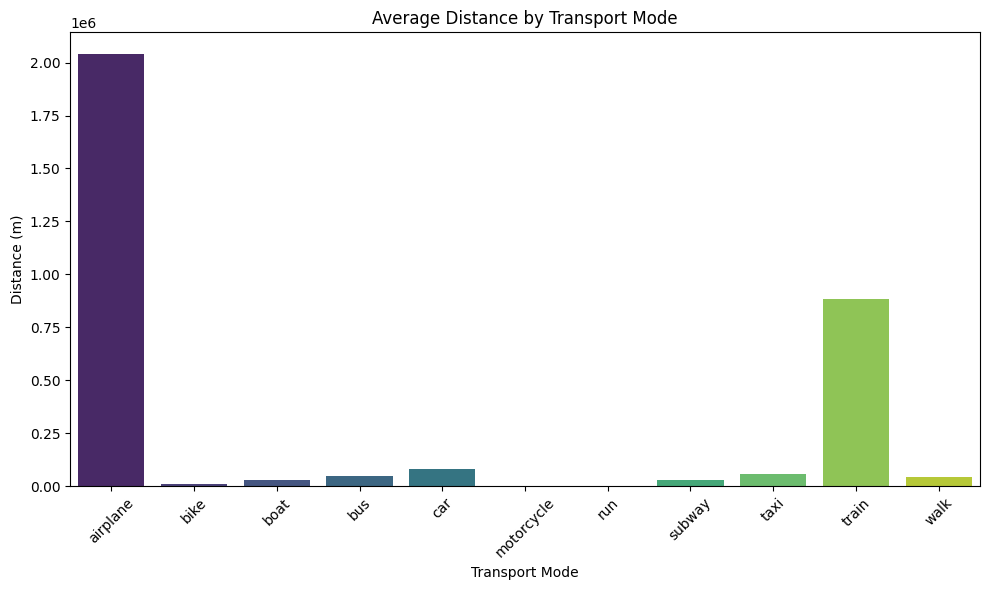

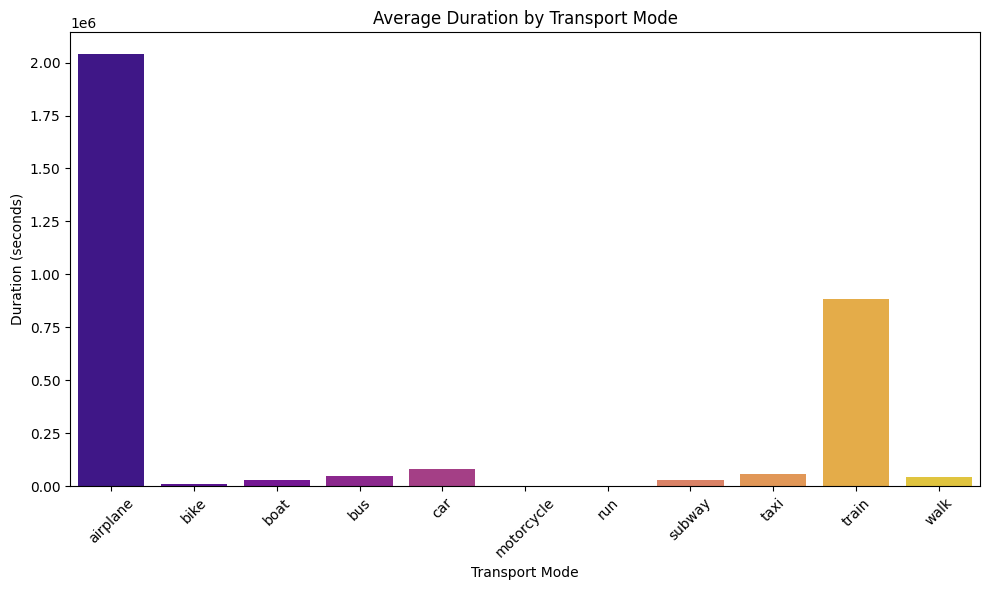

In [7]:
# Analyzing the average velocity by transport mode 
plt.figure(figsize=(10, 6))
sns.barplot(data=transport_stats, x='Transport_Mode', y='Vel_Mean', palette='coolwarm')
plt.title('Average Velocity by Transport Mode')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Analyzing the distribution of distances by transport mode
plt.figure(figsize=(10, 6))
sns.barplot(data=transport_stats, x='Transport_Mode', y='Dist_Mean', palette='viridis')
plt.title('Average Distance by Transport Mode')
plt.ylabel('Distance (m)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# Analyzing the distribution of durations by transport mode
plt.figure(figsize=(10, 6))
sns.barplot(data=transport_stats, x='Transport_Mode', y='Dist_Mean', palette='plasma')
plt.title('Average Duration by Transport Mode')
plt.ylabel('Duration (seconds)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


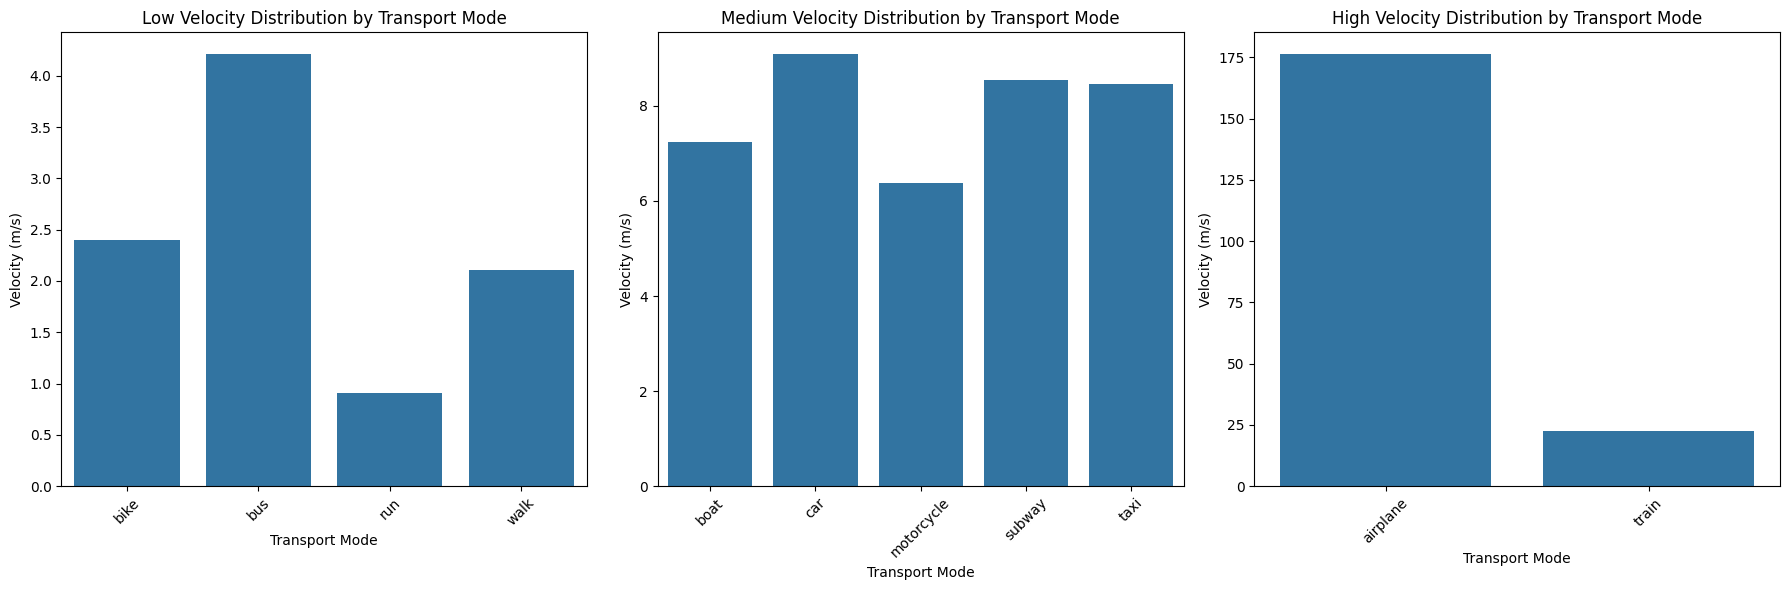

In [36]:
# Analyzing the distribution of velocity by transport mode
# Define a threshold for high and low velocity
SMALL_VELOCITY_THREASHOLD = 5
MEDIUM_VELOCITY_THRESHOLD = 20

high_velocity = transport_stats[transport_stats['Vel_Mean'] > MEDIUM_VELOCITY_THRESHOLD]
medium_velocity = transport_stats[
    (transport_stats['Vel_Mean'] <= MEDIUM_VELOCITY_THRESHOLD) & 
    (transport_stats['Vel_Mean'] > SMALL_VELOCITY_THREASHOLD)
]
low_velocity = transport_stats[
    transport_stats['Vel_Mean'] <= SMALL_VELOCITY_THREASHOLD
]
# Splitting the dataset into high, medium, low velocity based on the threshold
plt.figure(figsize=(18, 6)) 

# Low velocity
plt.subplot(1, 3, 1)
sns.barplot(data=low_velocity, x='Transport_Mode', y='Vel_Mean')
plt.title('Low Velocity Distribution by Transport Mode')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

# Medium velocity
plt.subplot(1, 3, 2)
sns.barplot(data=medium_velocity, x='Transport_Mode', y='Vel_Mean')
plt.title('Medium Velocity Distribution by Transport Mode')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)


# High velocity
plt.subplot(1, 3, 3)
sns.barplot(data=high_velocity, x='Transport_Mode', y='Vel_Mean')
plt.title('High Velocity Distribution by Transport Mode')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


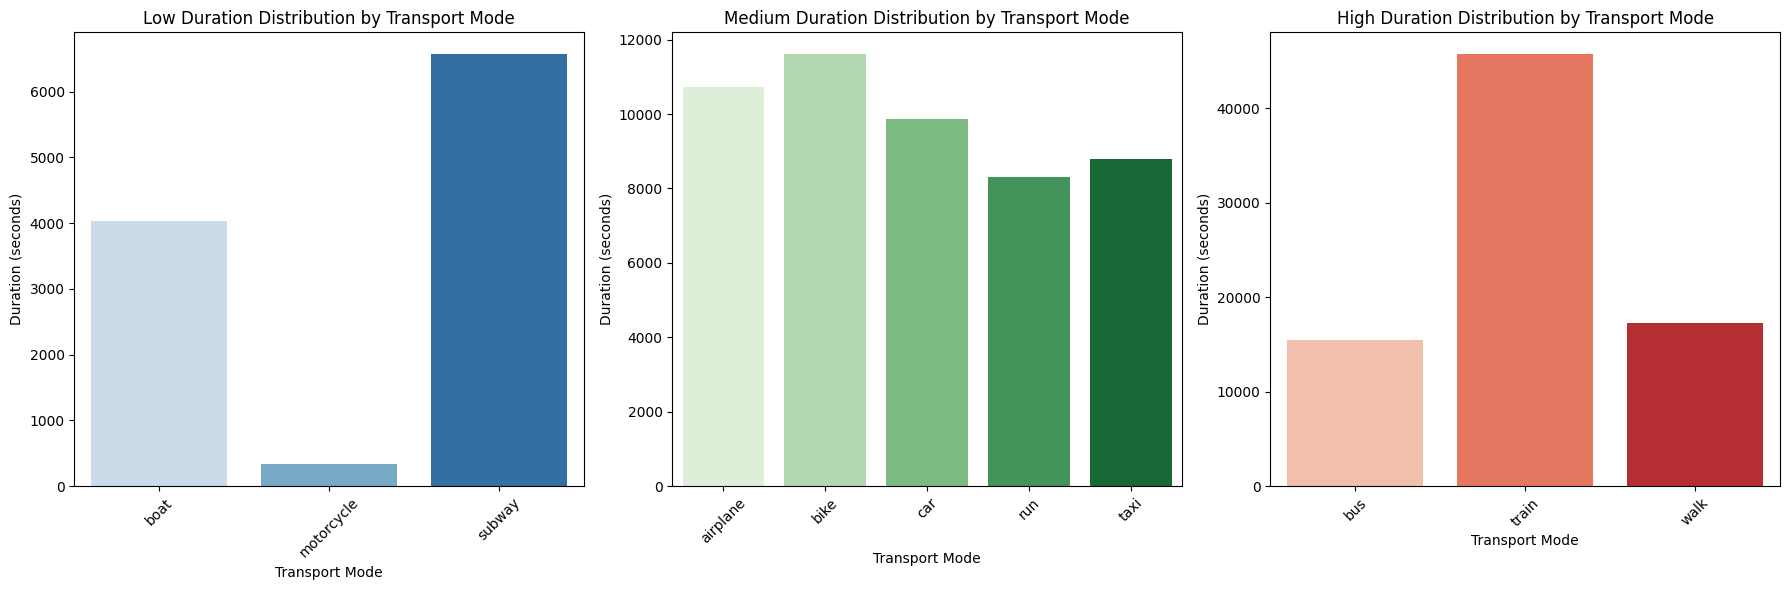

In [43]:
# Analyzing the distribution of duration by transport mode
# Define a threshold for high and low duration
SHORT_DURATION_THRESHOLD = 8000
MEDIUM_DURATION_THRESHOLD = 15000

# Splitting the dataset into high, medium, low duration based on the threshold
high_duration = transport_stats[transport_stats['Dur_Mean'] > MEDIUM_DURATION_THRESHOLD]
medium_duration = transport_stats[
    (transport_stats['Dur_Mean'] <= MEDIUM_DURATION_THRESHOLD) & 
    (transport_stats['Dur_Mean'] > SHORT_DURATION_THRESHOLD)
]
low_duration = transport_stats[transport_stats['Dur_Mean'] <= SHORT_DURATION_THRESHOLD]

plt.figure(figsize=(18, 6))

# Low duration
plt.subplot(1, 3, 1)
sns.barplot(data=low_duration, x='Transport_Mode', y='Dur_Mean', palette='Blues')
plt.title('Low Duration Distribution by Transport Mode')
plt.ylabel('Duration (seconds)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

# Medium duration
plt.subplot(1, 3, 2)
sns.barplot(data=medium_duration, x='Transport_Mode', y='Dur_Mean', palette='Greens')
plt.title('Medium Duration Distribution by Transport Mode')
plt.ylabel('Duration (seconds)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

# High duration
plt.subplot(1, 3, 3)
sns.barplot(data=high_duration, x='Transport_Mode', y='Dur_Mean', palette='Reds')
plt.title('High Duration Distribution by Transport Mode')
plt.ylabel('Duration (seconds)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


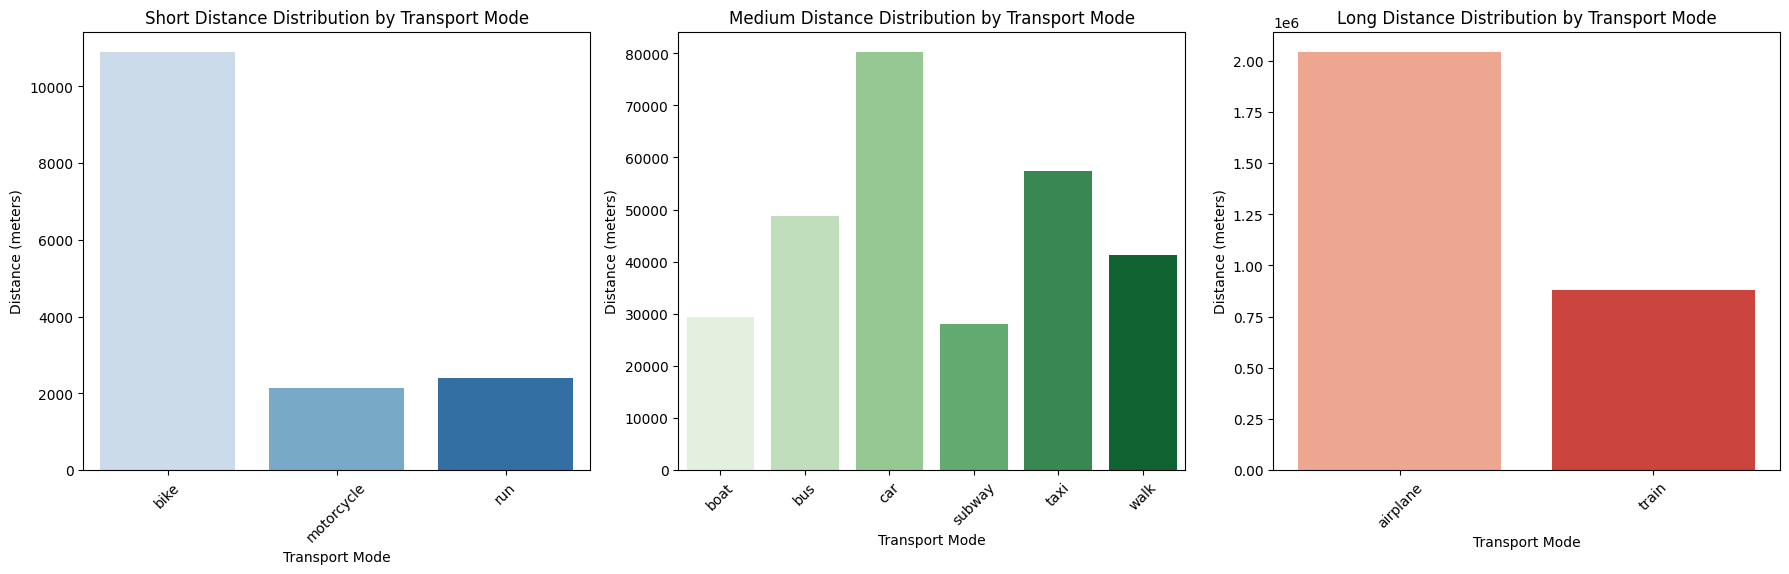

In [48]:
# Analyzing the distribution of distance by transport mode
# Define thresholds for short, medium, and long distances
SHORT_DISTANCE_THRESHOLD = 20000
MEDIUM_DISTANCE_THRESHOLD = 500000

# Splitting the dataset into short, medium, and long distances based on the threshold
long_distance = transport_stats[transport_stats['Dist_Mean'] > MEDIUM_DISTANCE_THRESHOLD]
medium_distance = transport_stats[
    (transport_stats['Dist_Mean'] <= MEDIUM_DISTANCE_THRESHOLD) & 
    (transport_stats['Dist_Mean'] > SHORT_DISTANCE_THRESHOLD)
]
short_distance = transport_stats[transport_stats['Dist_Mean'] <= SHORT_DISTANCE_THRESHOLD]

plt.figure(figsize=(18, 6))

# Short distance
plt.subplot(1, 3, 1)
sns.barplot(data=short_distance, x='Transport_Mode', y='Dist_Mean', palette='Blues')
plt.title('Short Distance Distribution by Transport Mode')
plt.ylabel('Distance (meters)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

# Medium distance
plt.subplot(1, 3, 2)
sns.barplot(data=medium_distance, x='Transport_Mode', y='Dist_Mean', palette='Greens')
plt.title('Medium Distance Distribution by Transport Mode')
plt.ylabel('Distance (meters)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

# Long distance
plt.subplot(1, 3, 3)
sns.barplot(data=long_distance, x='Transport_Mode', y='Dist_Mean', palette='Reds')
plt.title('Long Distance Distribution by Transport Mode')
plt.ylabel('Distance (meters)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


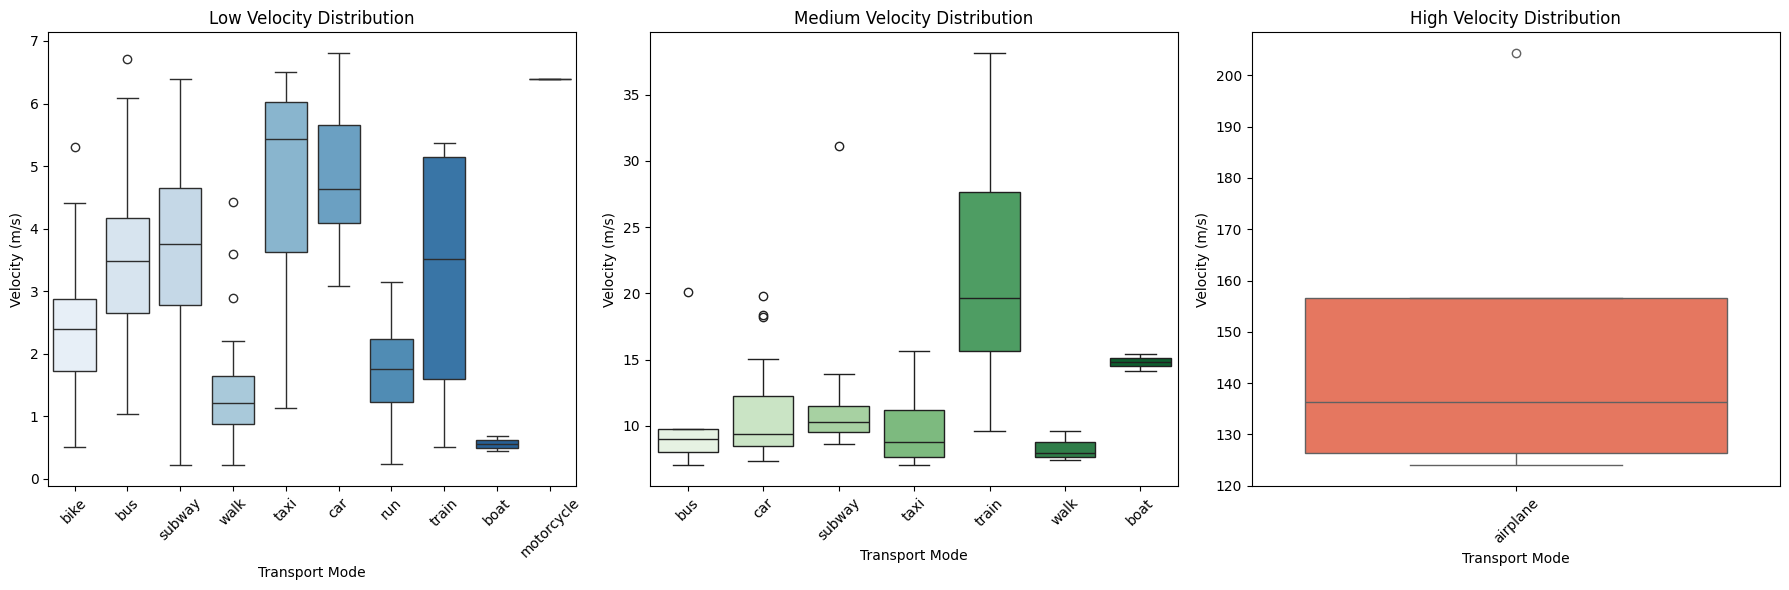

In [70]:
# Splitting the dataset into low, medium, and high velocity based on thresholds
USER_SMALL_VELOCITY_THREASHOLD = 7
USER_MEDIUM_VELOCITY_THRESHOLD = 50

low_velocity = user_stats[user_stats[('velocity', 'mean')] <= USER_SMALL_VELOCITY_THREASHOLD]
medium_velocity = user_stats[
    (user_stats[('velocity', 'mean')] > USER_SMALL_VELOCITY_THREASHOLD) & 
    (user_stats[('velocity', 'mean')] <= USER_MEDIUM_VELOCITY_THRESHOLD)
]
high_velocity = user_stats[user_stats[('velocity', 'mean')] > USER_MEDIUM_VELOCITY_THRESHOLD]

# Creating box plots for each category
plt.figure(figsize=(18, 6))

# Low velocity
plt.subplot(1, 3, 1)
sns.boxplot(data=low_velocity, x=('label', ), y=('velocity', 'mean'), palette='Blues')
plt.title('Low Velocity Distribution')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

# Medium velocity
plt.subplot(1, 3, 2)
sns.boxplot(data=medium_velocity, x=('label', ), y=('velocity', 'mean'), palette='Greens')
plt.title('Medium Velocity Distribution')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

# High velocity
plt.subplot(1, 3, 3)
sns.boxplot(data=high_velocity, x=('label', ), y=('velocity', 'mean'), palette='Reds')
plt.title('High Velocity Distribution')
plt.ylabel('Velocity (m/s)')
plt.xlabel('Transport Mode')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


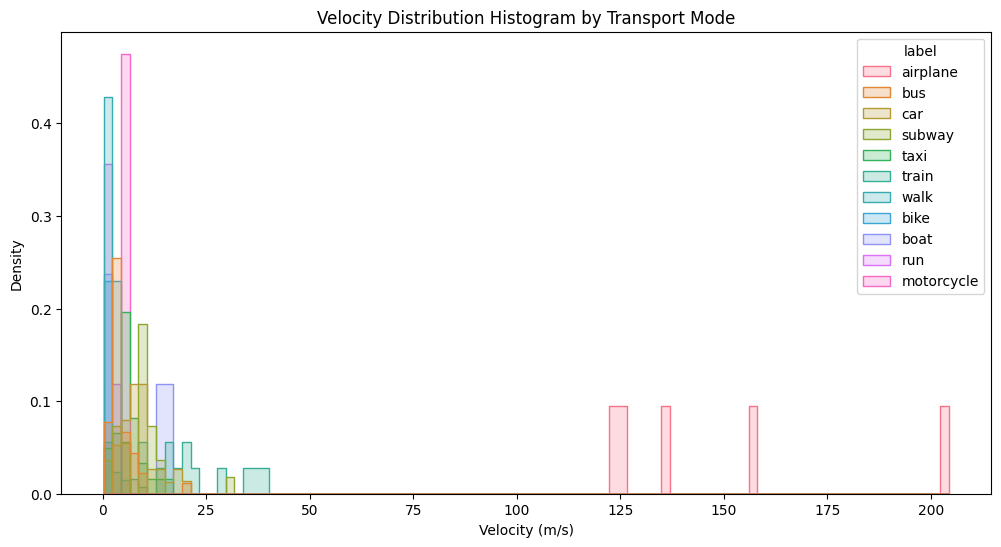

In [51]:
plt.figure(figsize=(12, 6))
sns.histplot(data=user_stats, x=('velocity', 'mean'), hue='label', element='step', stat='density', common_norm=False)
plt.title('Velocity Distribution Histogram by Transport Mode')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Density')
plt.show()


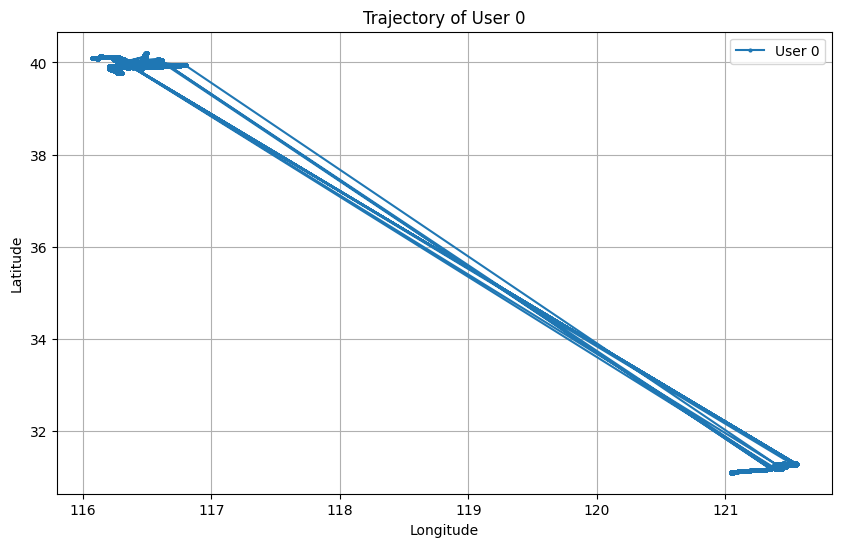

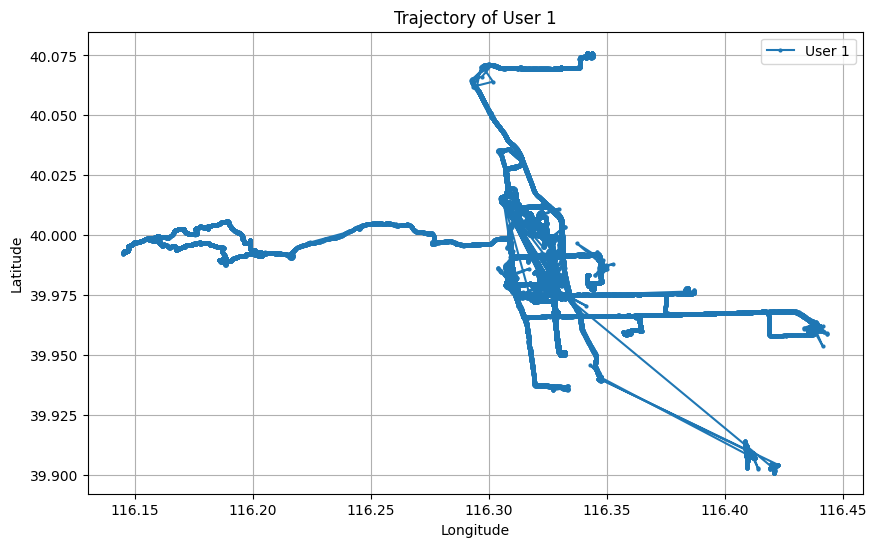

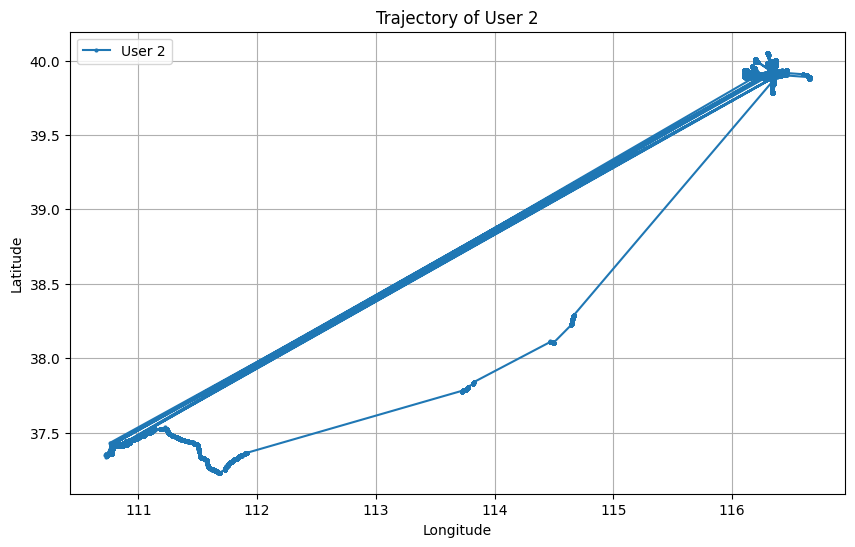

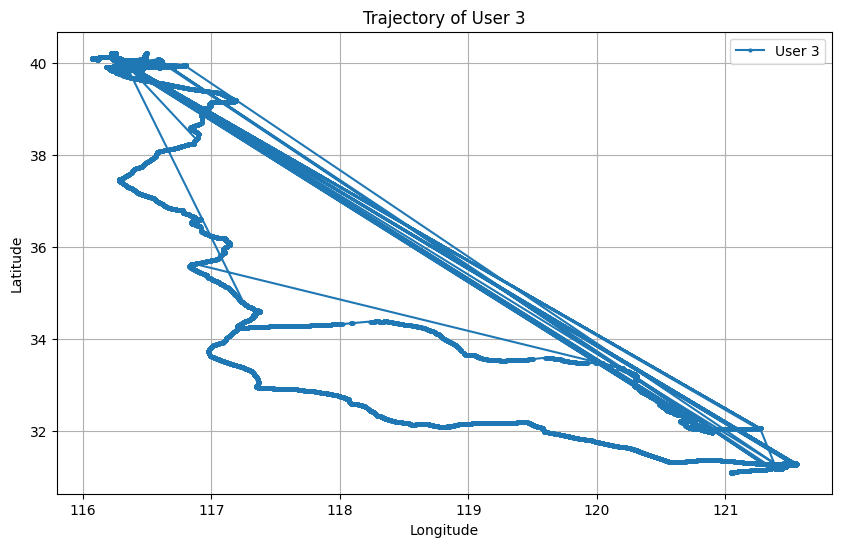

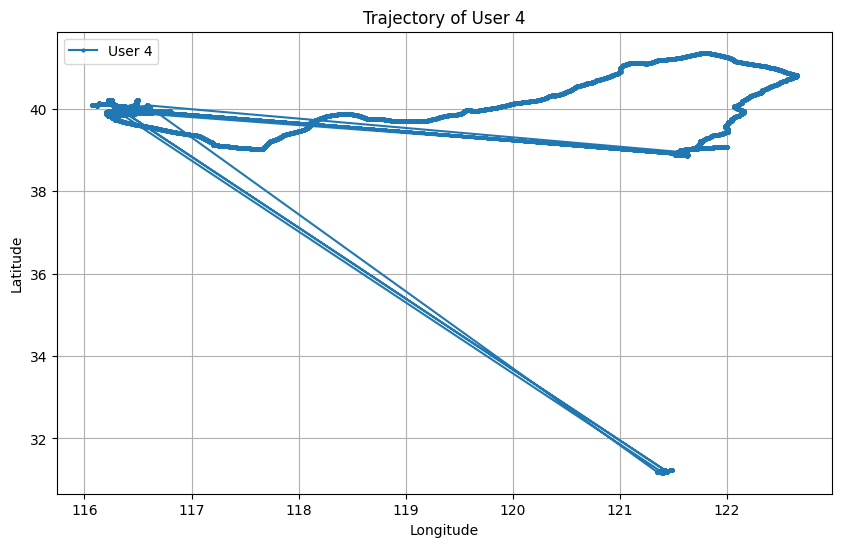

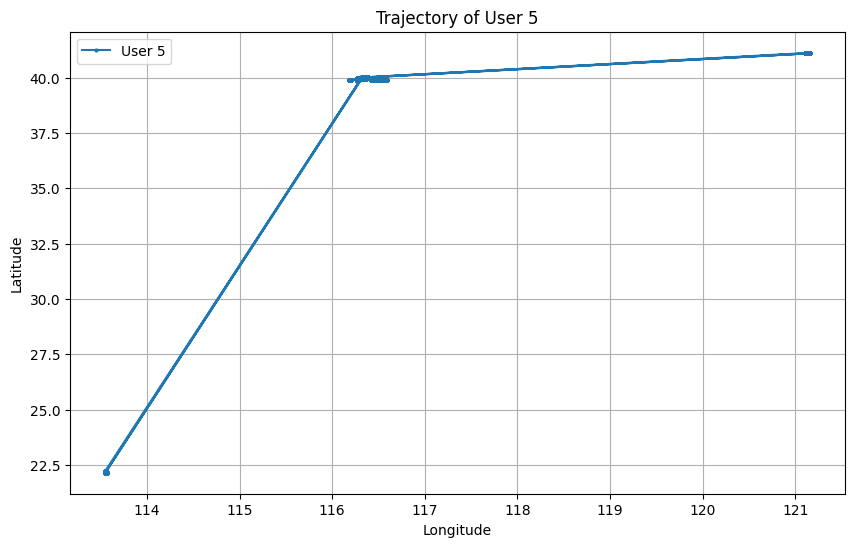

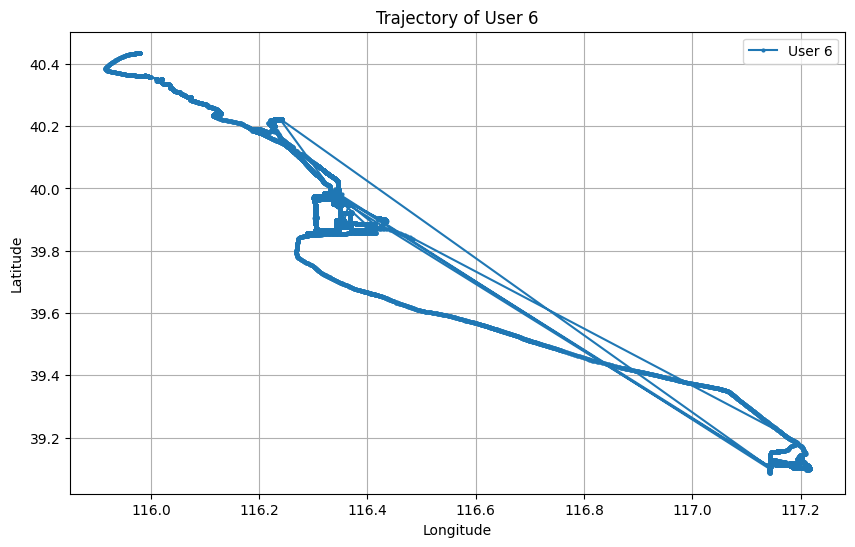

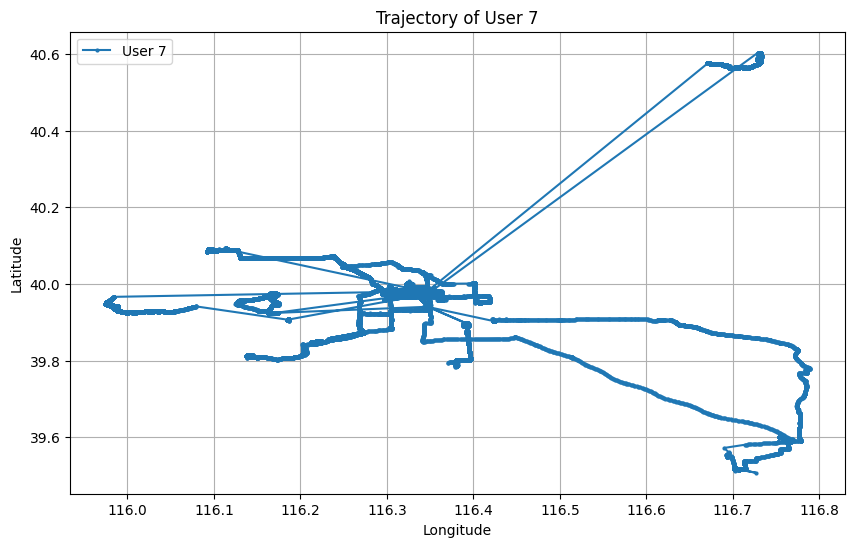

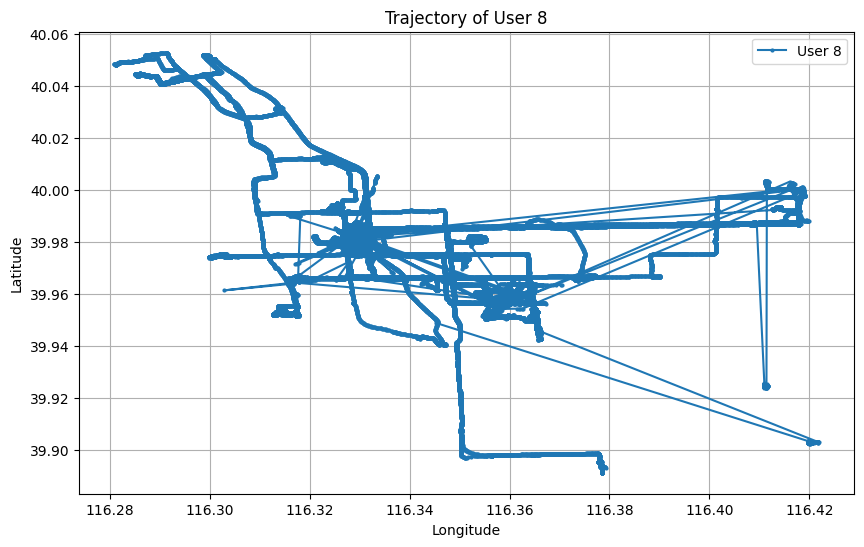

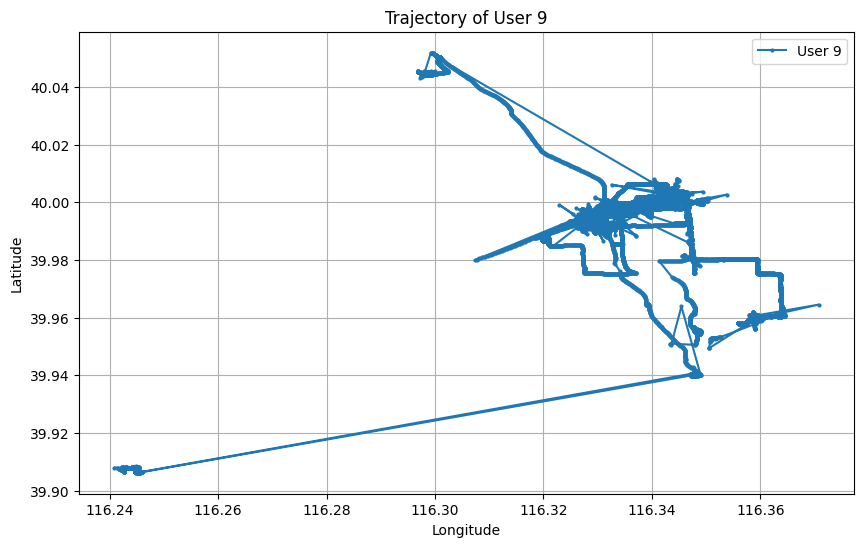

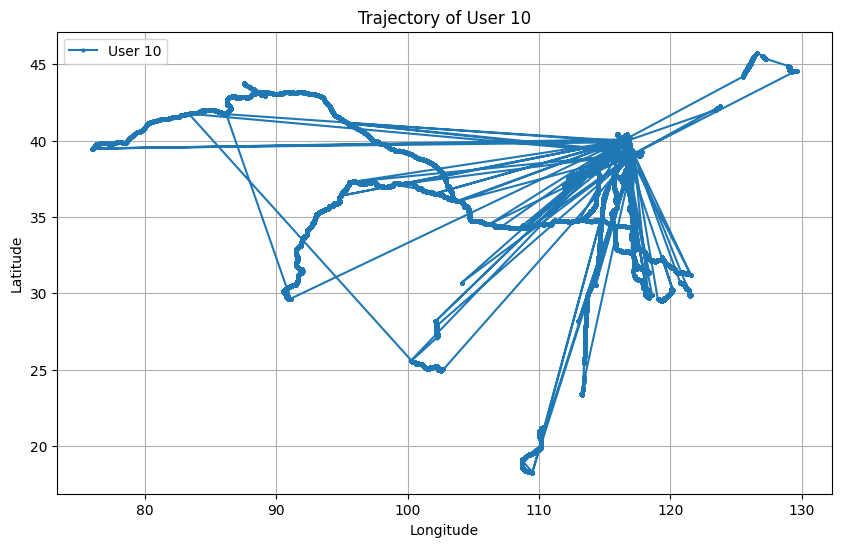

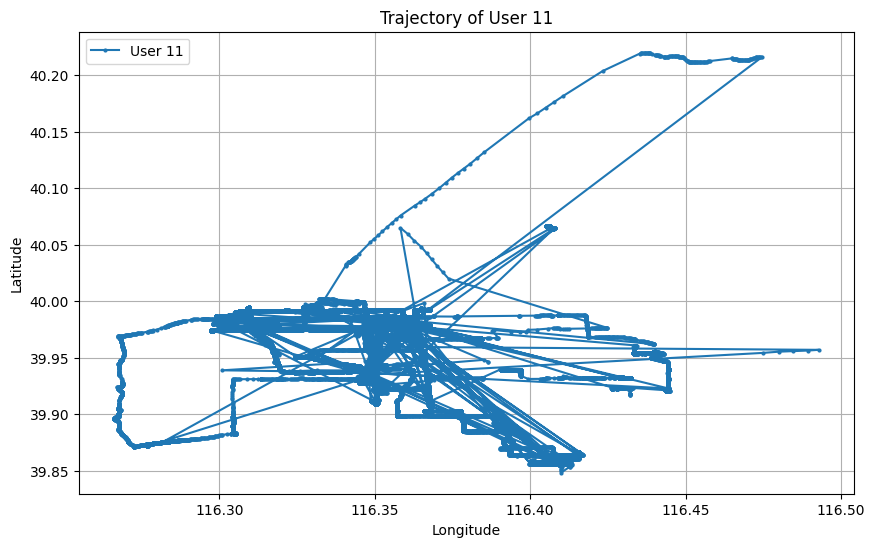

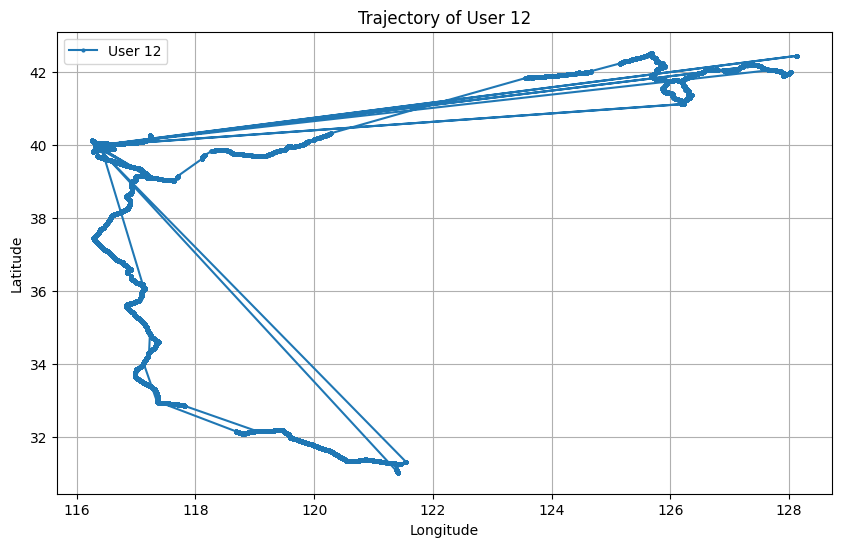

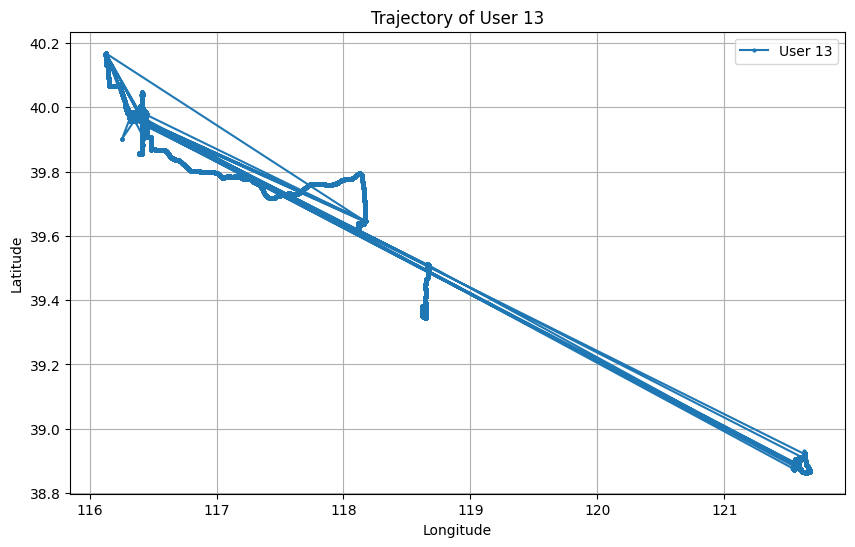

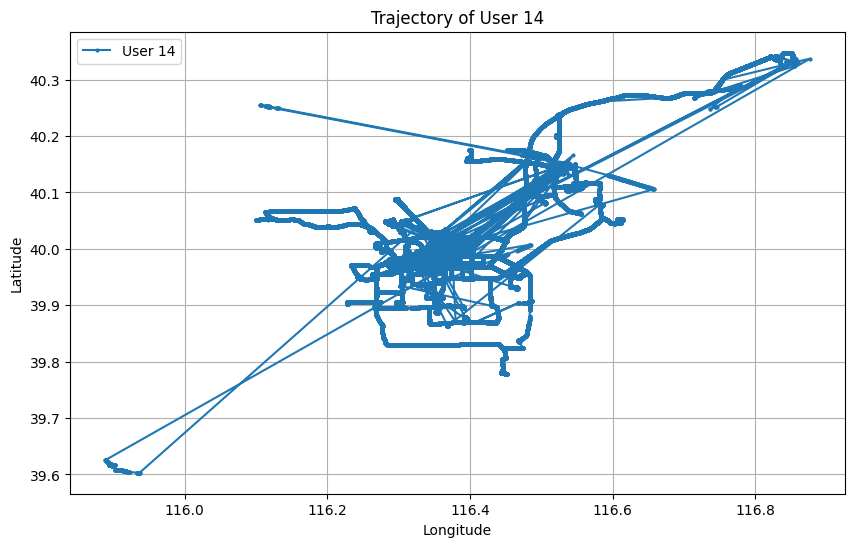

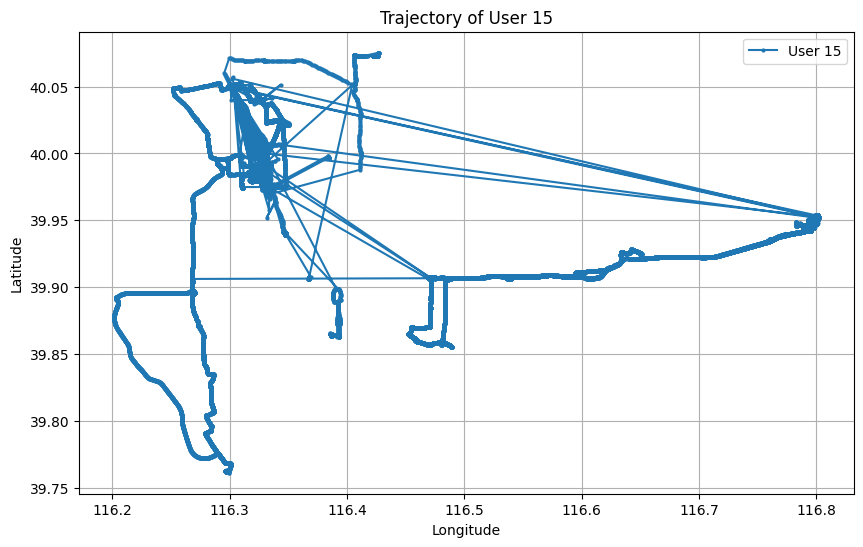

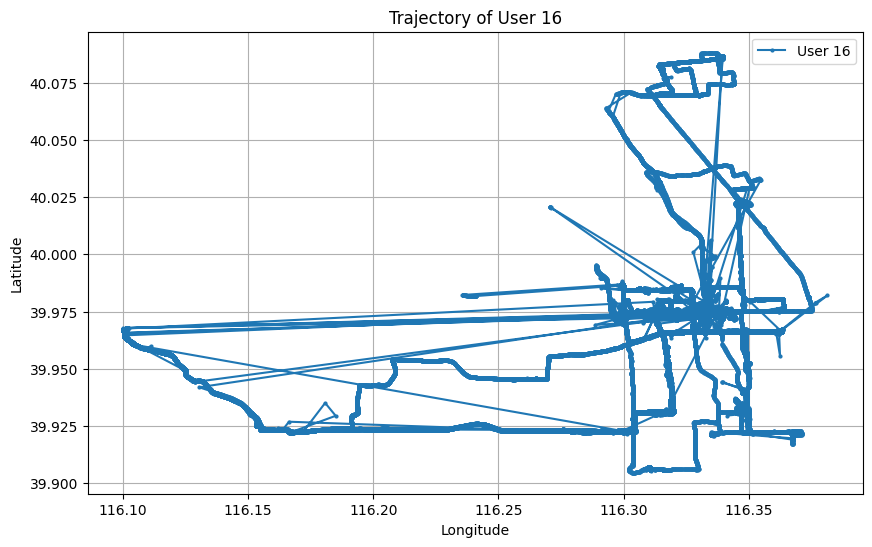

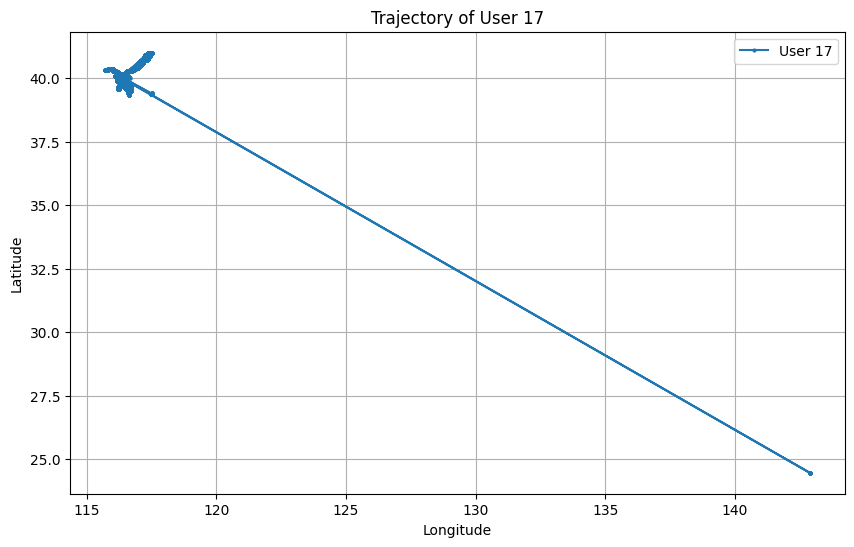

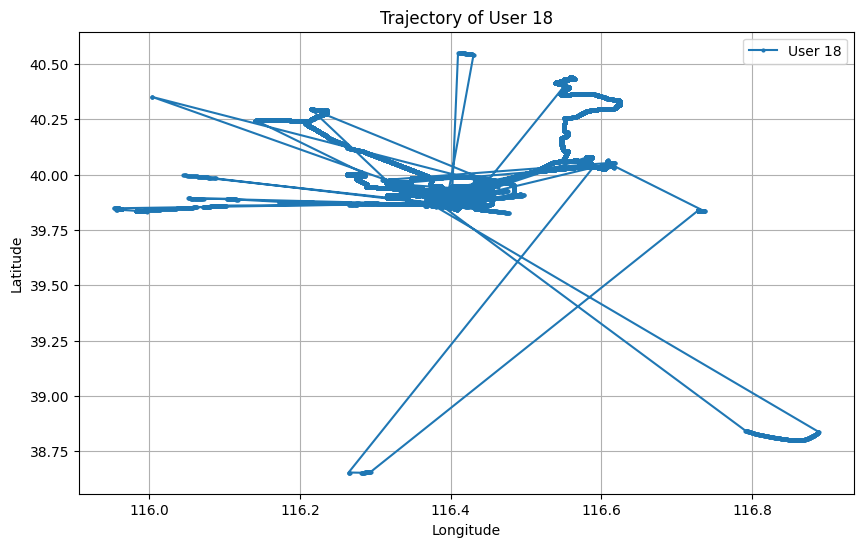

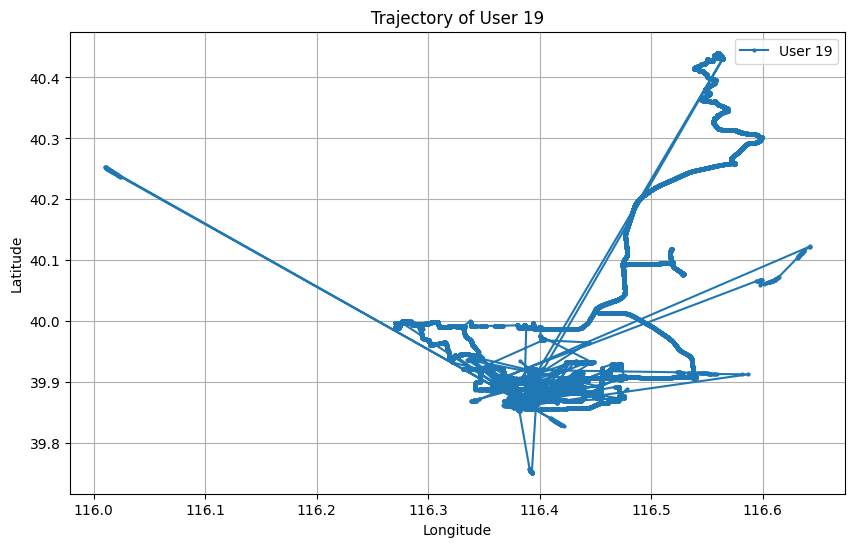

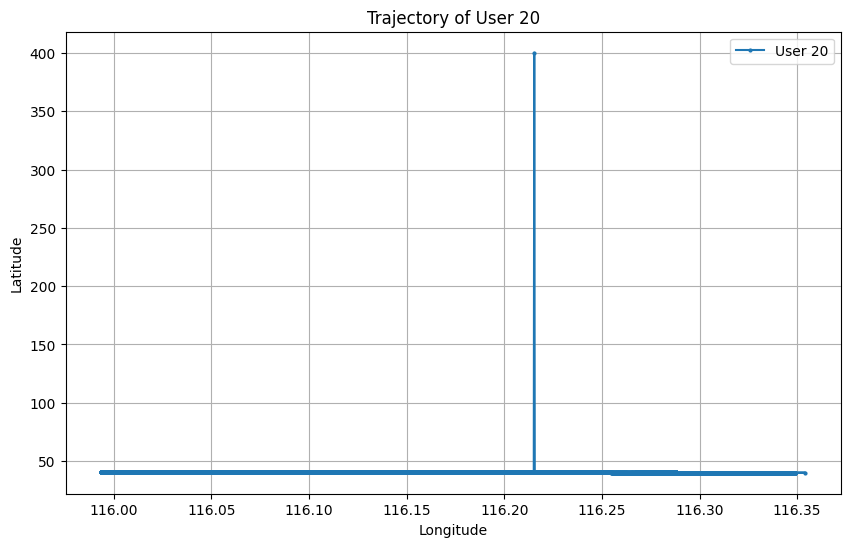

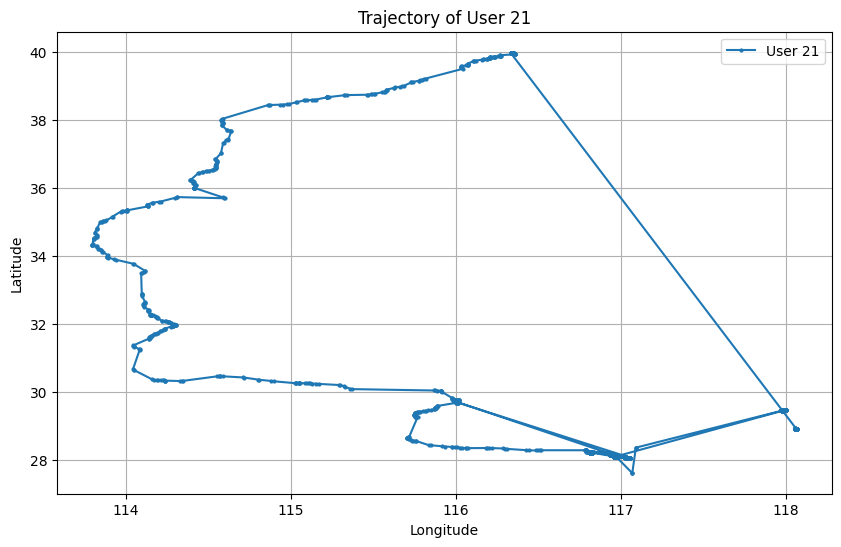

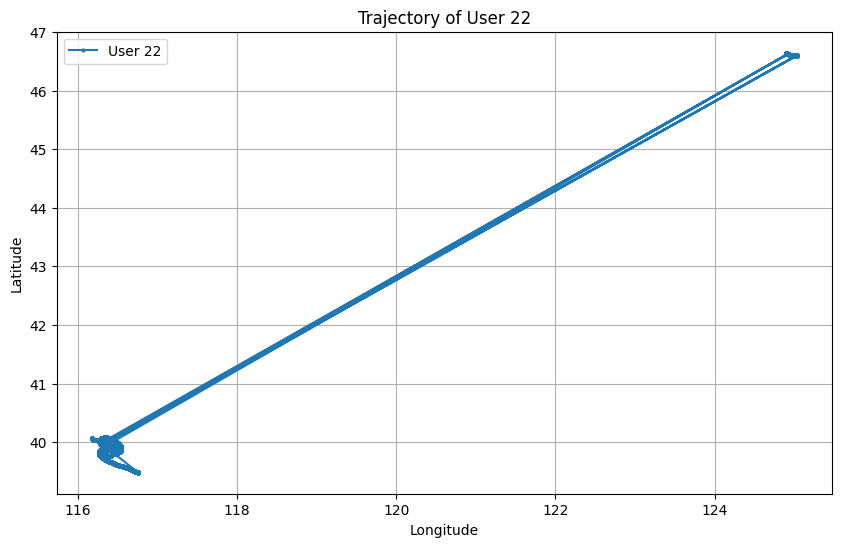

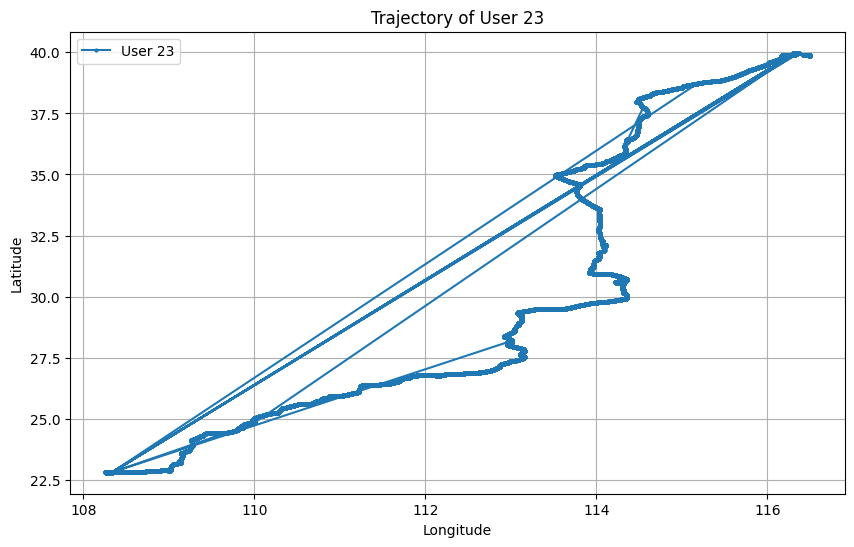

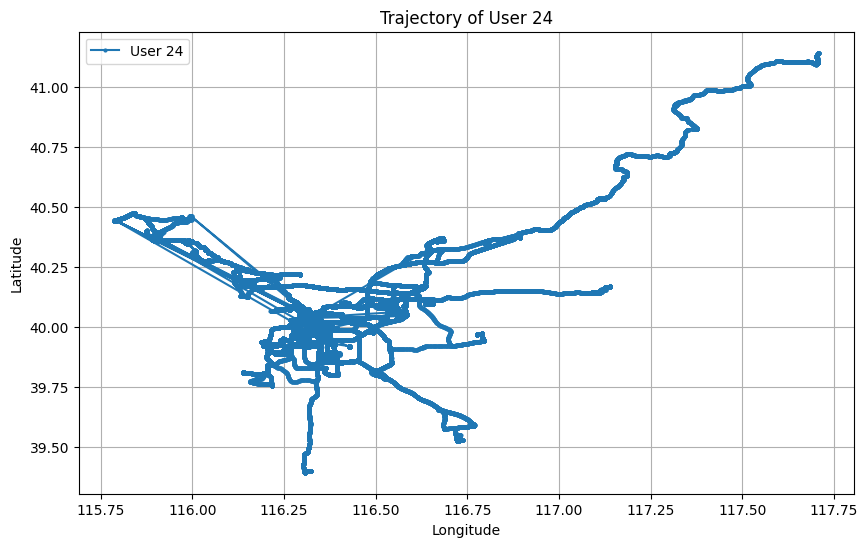

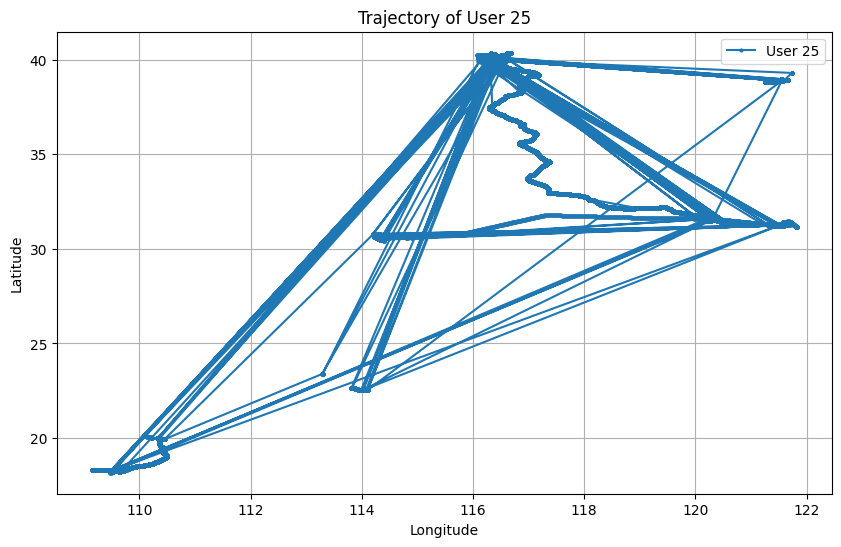

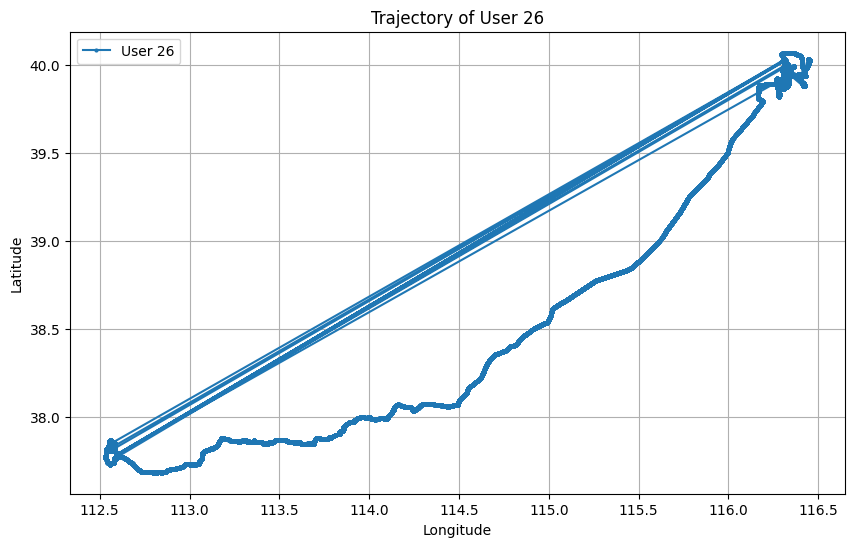

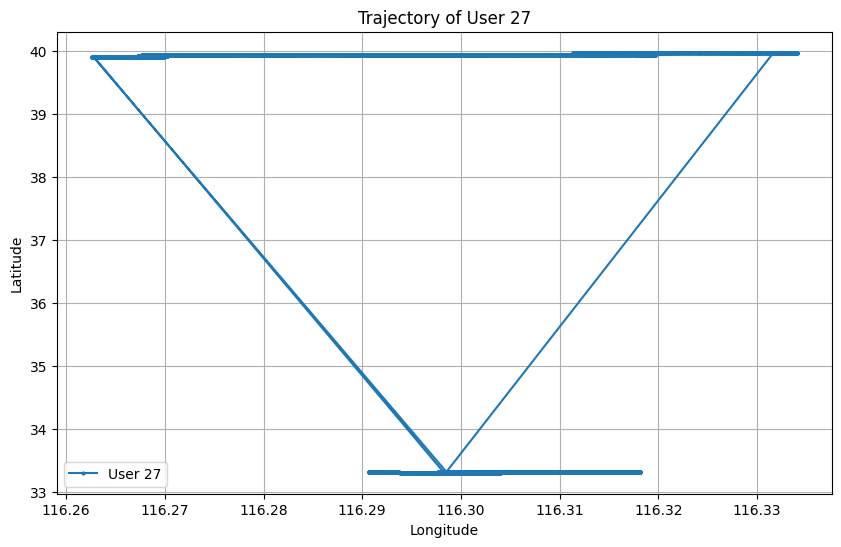

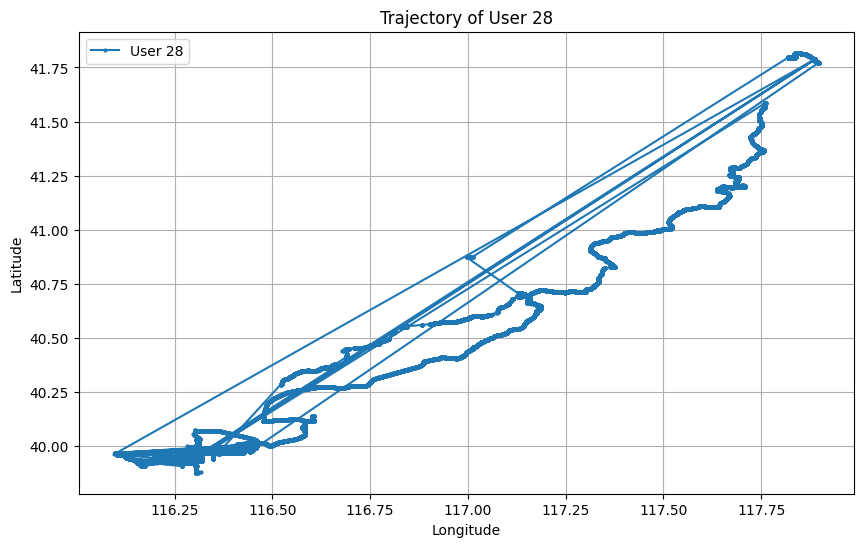

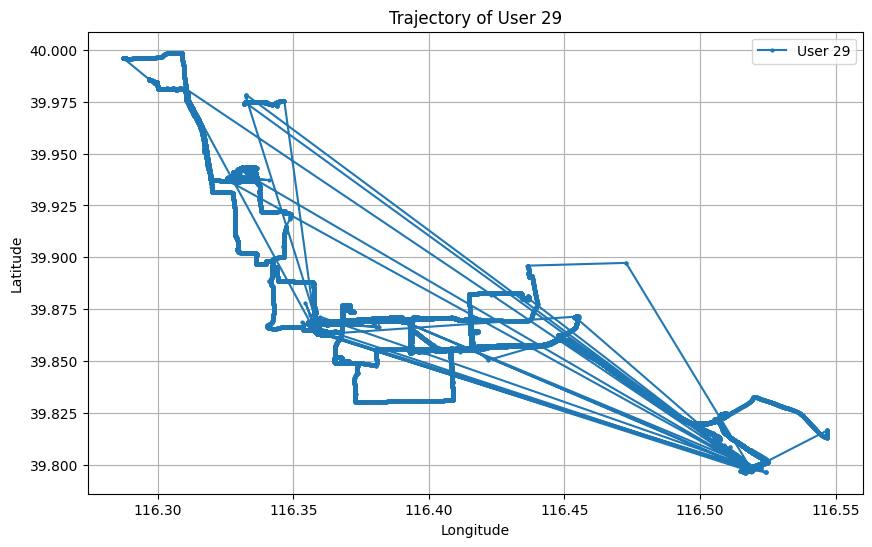

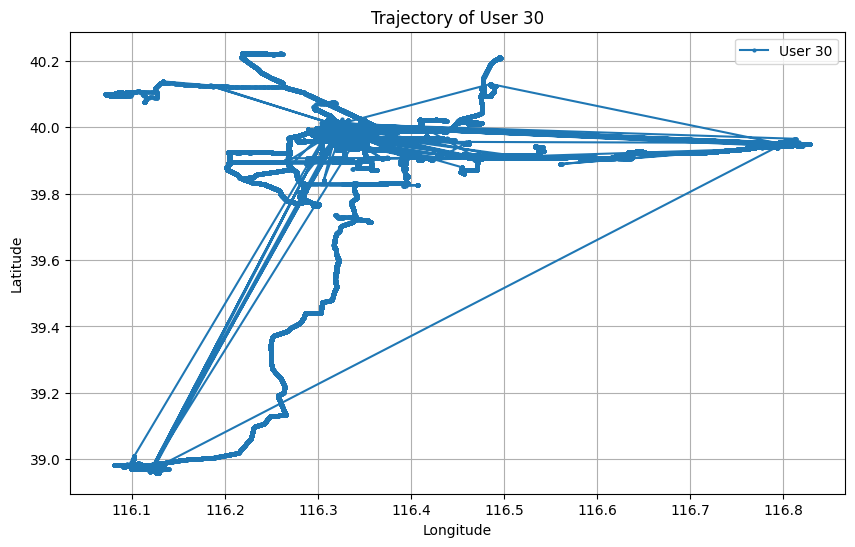

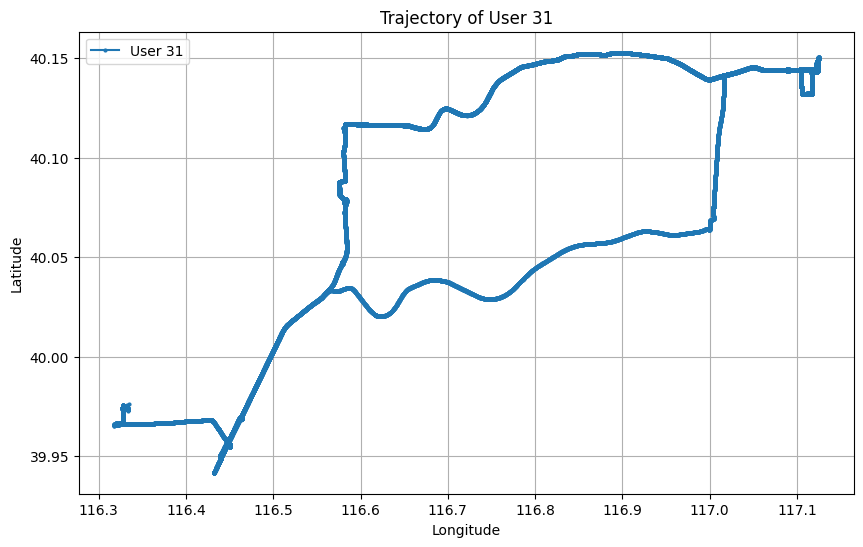

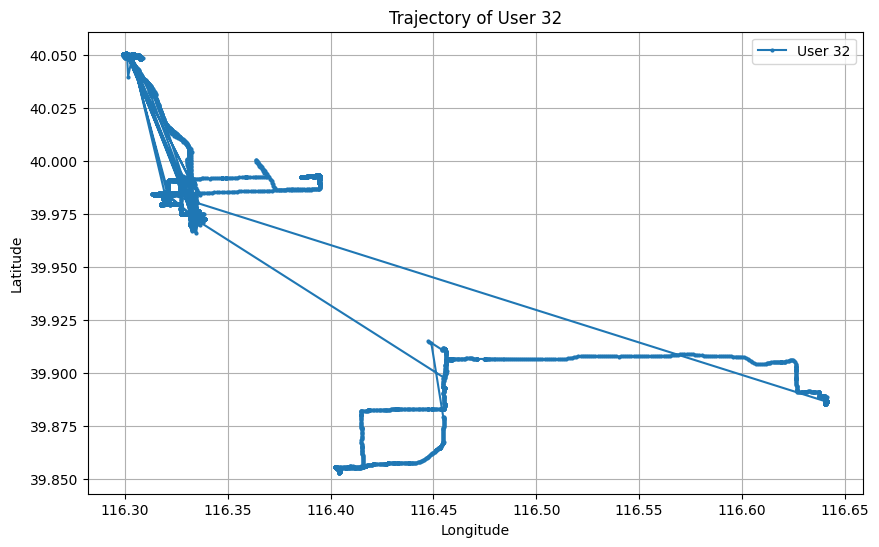

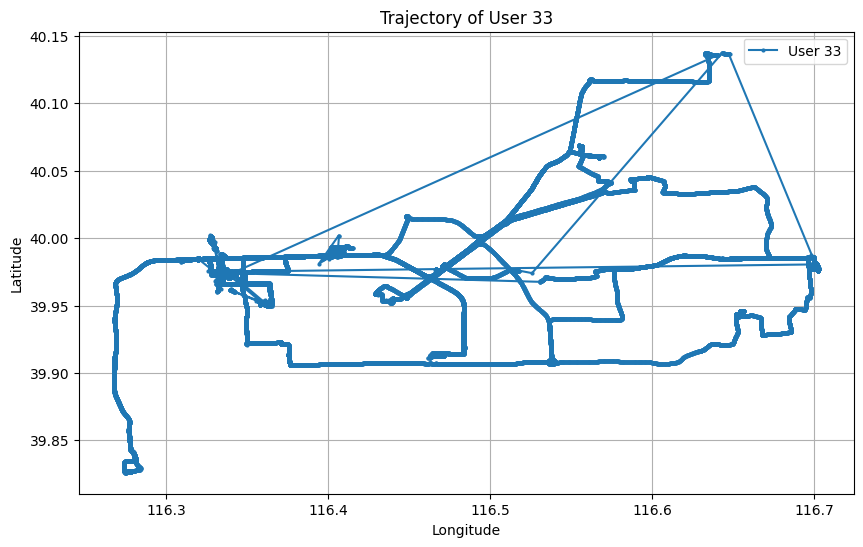

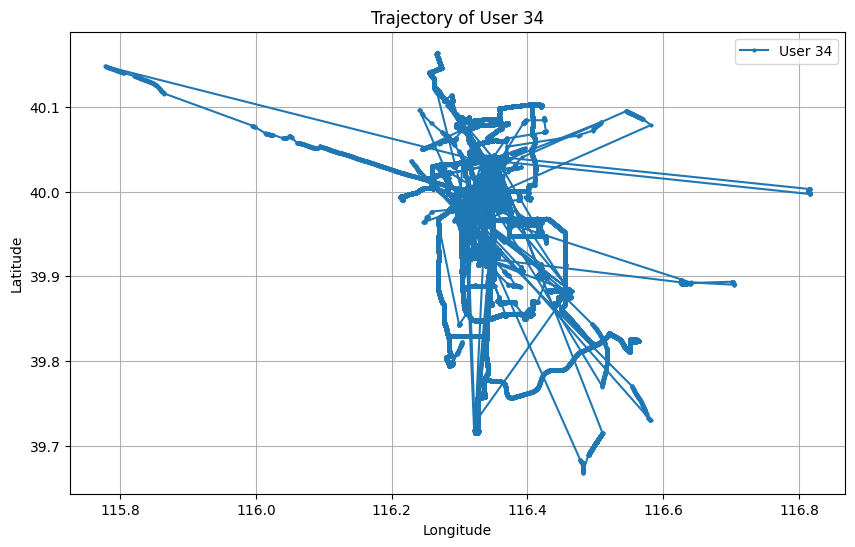

KeyboardInterrupt: 

In [71]:
# Plot data into the map to identify patterns for each means of transportation
for uid, group in location_data.data.groupby('uid'):
    plt.figure(figsize=(10, 6))
    plt.plot(group['lon'], group['lat'], marker='o', linestyle='-', markersize=2, label=f'User {uid}')
    plt.title(f'Trajectory of User {uid}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.show()

In [11]:
# Select a user with multi-modal transport usage
user_id = df['uid'].value_counts().idxmax()  # Example: user with most records
user_data = df[df['uid'] == user_id]

# Analyze user patterns
print(f"Analyzing patterns for user {user_id}:")
user_patterns = user_data.groupby('label').agg({
    'distance': 'sum',
    'duration': 'sum',
    'velocity': 'mean'
}).reset_index()

display(user_patterns)

Analyzing patterns for user 68:


,label,distance,duration,velocity
0,bike,3.585216e+09,6.303487e+09,1.191958
1,bus,1.895190e+10,5.489264e+09,3.291709
2,car,4.747294e+08,6.887751e+07,7.629962
3,subway,1.757402e+08,2.247639e+07,8.634549
4,taxi,6.068316e+07,5.346654e+07,1.134974
5,train,2.182009e+10,6.111354e+08,35.975150
6,walk,1.211479e+09,1.134047e+09,1.139819


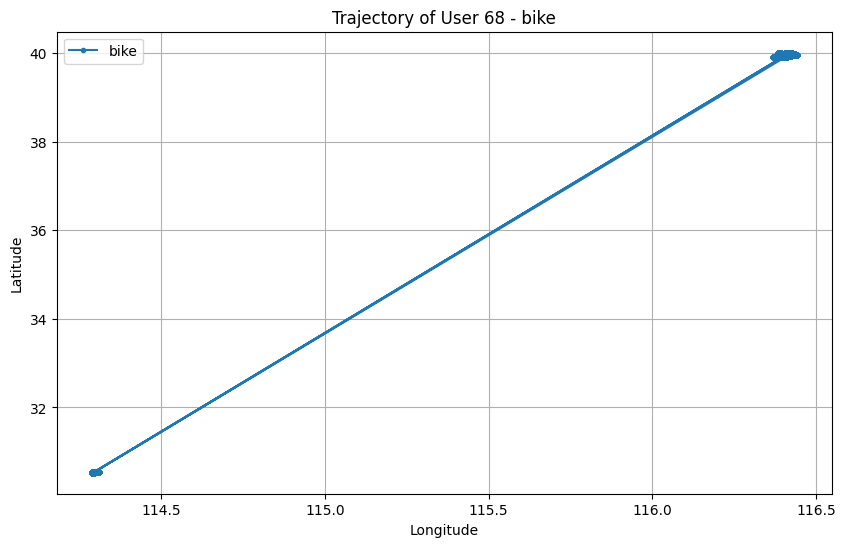

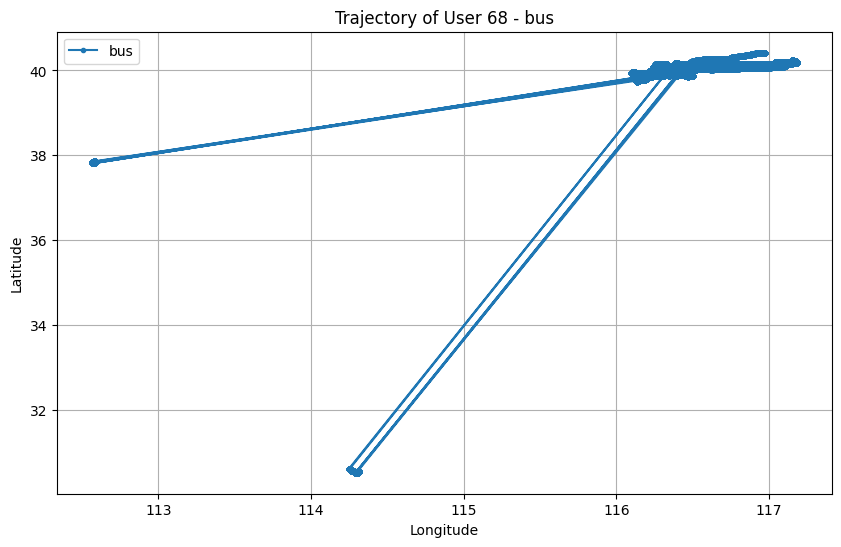

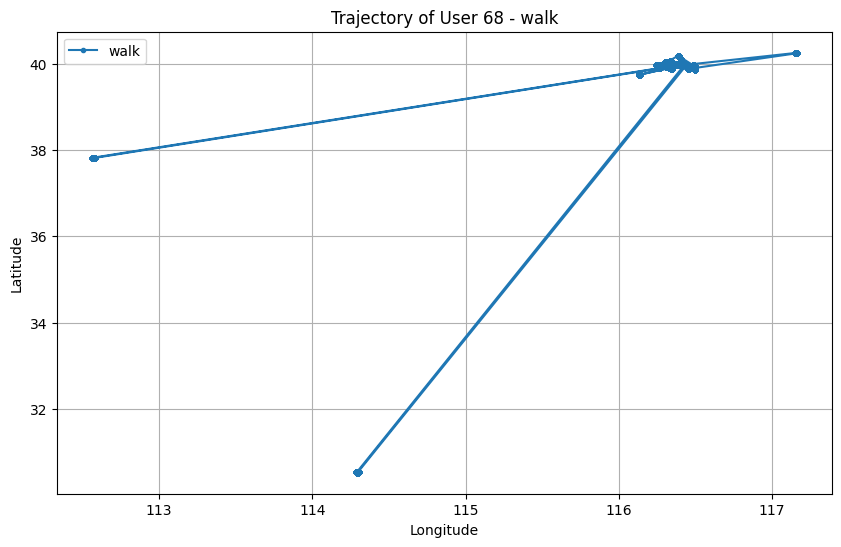

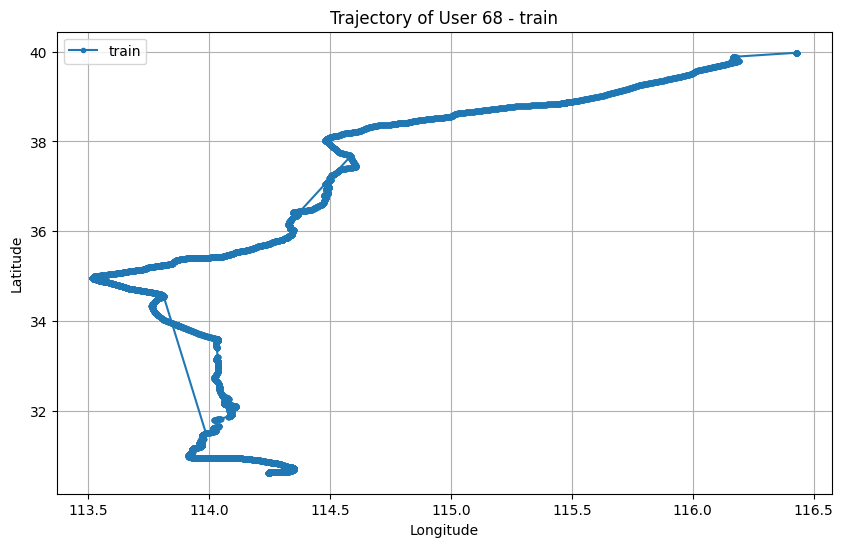

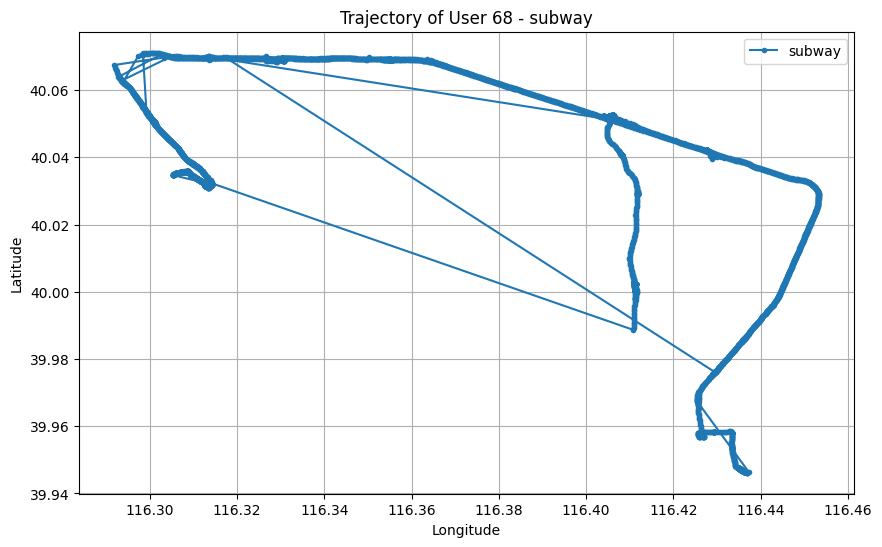

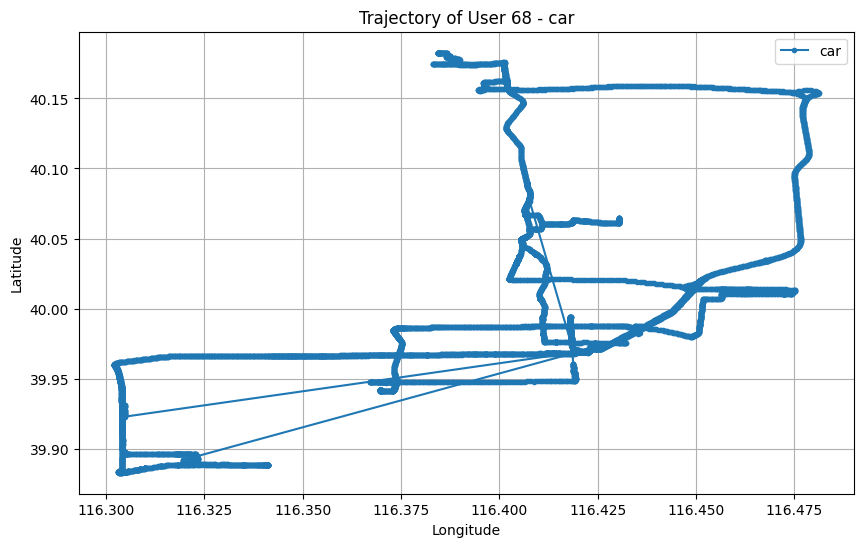

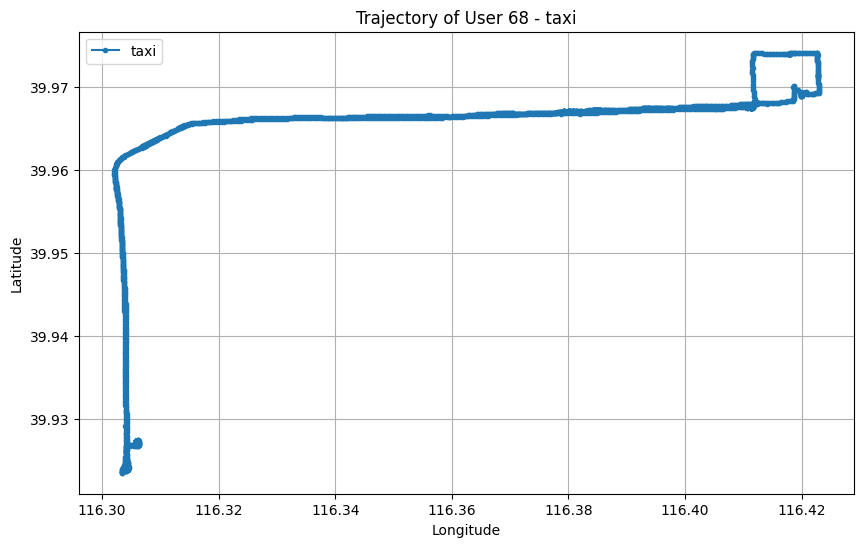

In [12]:
# Plot each means of transport in a separate figure
for label in user_data['label'].unique():
    subset = user_data[user_data['label'] == label]
    plt.figure(figsize=(10, 6))
    plt.plot(subset['lon'], subset['lat'], marker='o', linestyle='-', markersize=3, label=label)
    plt.title(f"Trajectory of User {user_id} - {label}")
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.show()


Daily Usage Statistics:


,date,label,distance,duration,velocity,count
0,2008-09-14,bike,1.656475e+05,75000.0,2.208633,125
1,2008-09-15,bike,3.076341e+07,56607498.0,0.543451,1539
2,2008-09-16,bike,6.535141e+06,8242688.0,0.792841,544
3,2008-09-16,bus,2.838731e+06,463450.0,6.125214,310
4,2008-09-16,walk,3.227501e+06,9747263.0,0.331119,433
...,...,...,...,...,...,...
426,2009-09-11,bike,1.736492e+07,28666698.0,0.605752,1567
427,2009-09-11,bus,9.239937e+07,85529279.0,1.080324,3377
428,2009-09-12,bus,5.940634e+07,13746613.0,4.560425,2876
429,2009-09-13,bike,1.262031e+06,581516.0,2.170244,422


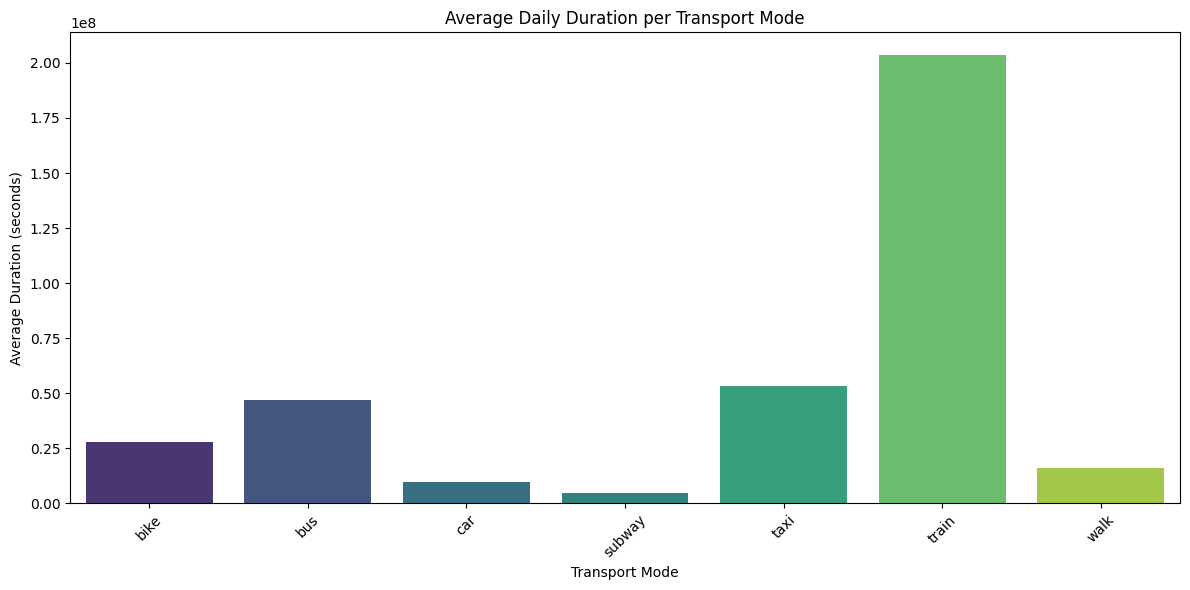

In [53]:
user_data['date'] = pd.to_datetime(user_data['datetime']).dt.date  
# Group by date and transport mode to analyze daily patterns
daily_usage = user_data.groupby(['date', 'label']).agg({
    'distance': 'sum',
    'duration': 'sum',
    'velocity': 'mean',
    'uid': 'count'  # count records to estimate frequency
}).rename(columns={'uid':'count'}).reset_index()
# Calculate the average duration per transport mode per day
daily_avg_duration = daily_usage.groupby('label')['duration'].mean().reset_index()
daily_avg_duration.columns = ['Transport_Mode', 'Avg_Duration']
# Display the daily usage statistics
print("\nDaily Usage Statistics:")
display(daily_usage)
# Plotting daily usage statistics
plt.figure(figsize=(12, 6))
sns.barplot(data=daily_avg_duration, x='Transport_Mode', y='Avg_Duration', palette='viridis')
plt.title('Average Daily Duration per Transport Mode')
plt.xlabel('Transport Mode')
plt.ylabel('Average Duration (seconds)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

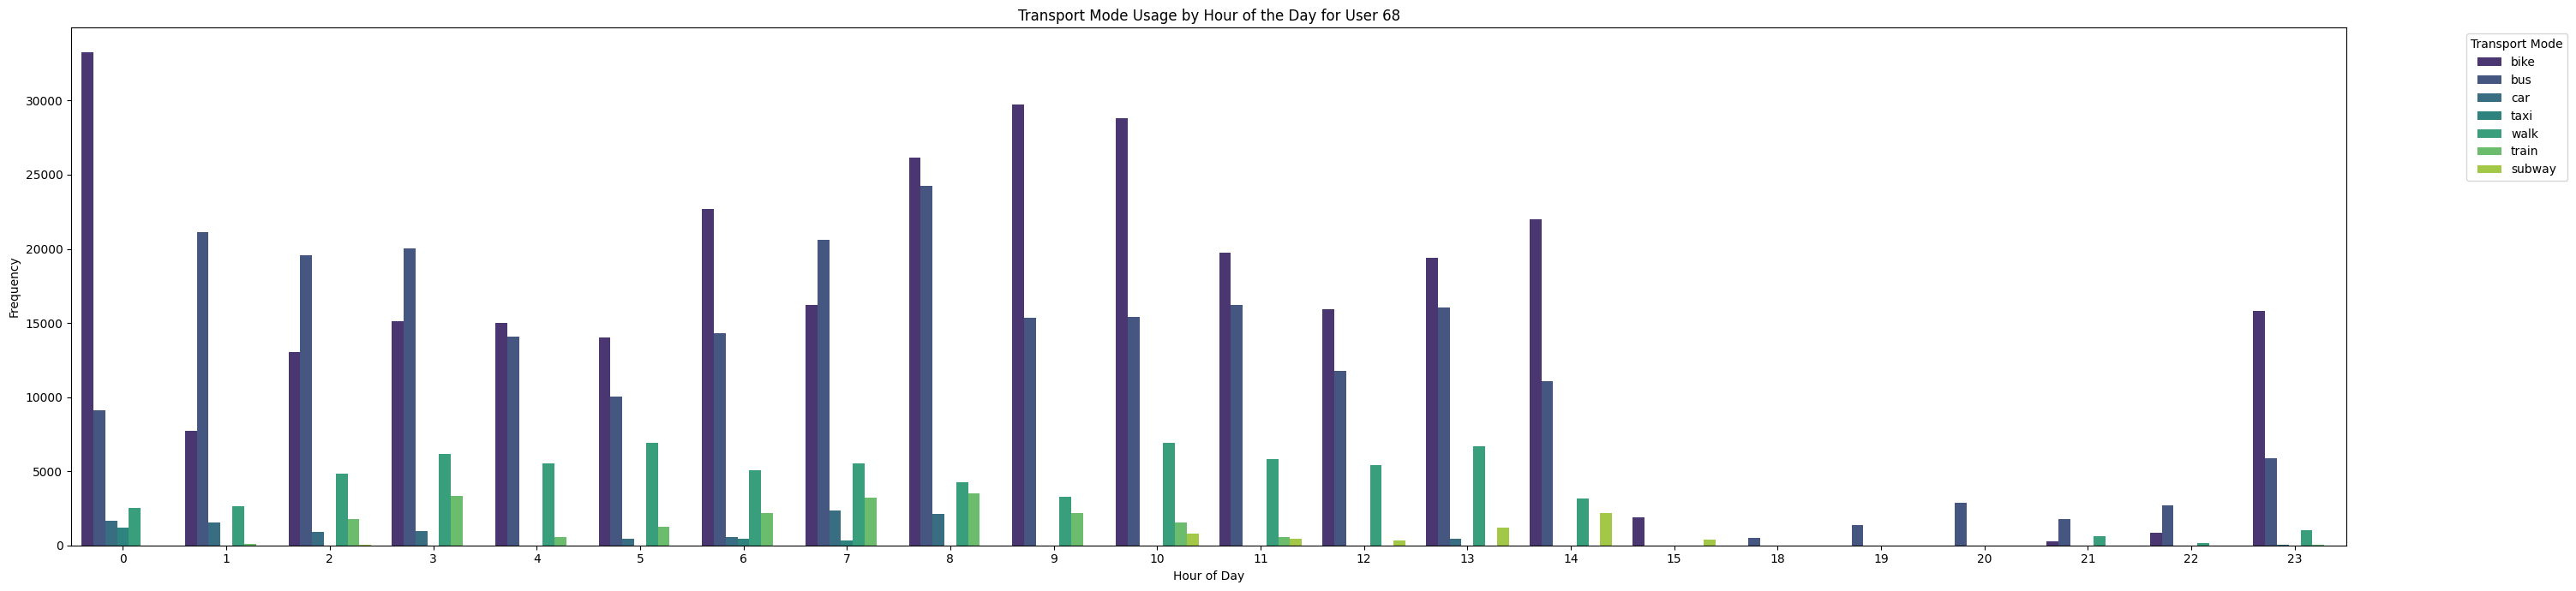

In [33]:
user_data['hour'] = pd.to_datetime(user_data['datetime']).dt.hour
hourly_usage = user_data.groupby(['hour', 'label']).size().reset_index(name='count')

plt.figure(figsize=(14, 7))
sns.barplot(data=hourly_usage, x='hour', y='count', hue='label', palette='viridis')
plt.title(f'Transport Mode Usage by Hour of the Day for User {user_id}')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.legend(title='Transport Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Most visited trajectories by transport mode:


,uid,label,lat,lon,count
611014,68,walk,39.867550,116.492032,43
611023,68,walk,39.867551,116.492035,30
621231,68,walk,39.918526,116.311587,27
611034,68,walk,39.867553,116.492037,23
620523,68,walk,39.917467,116.312686,23
...,...,...,...,...,...
226401,68,bike,39.984316,116.417770,1
226402,68,bike,39.984316,116.417820,1
226403,68,bike,39.984316,116.418035,1
226404,68,bike,39.984316,116.418062,1


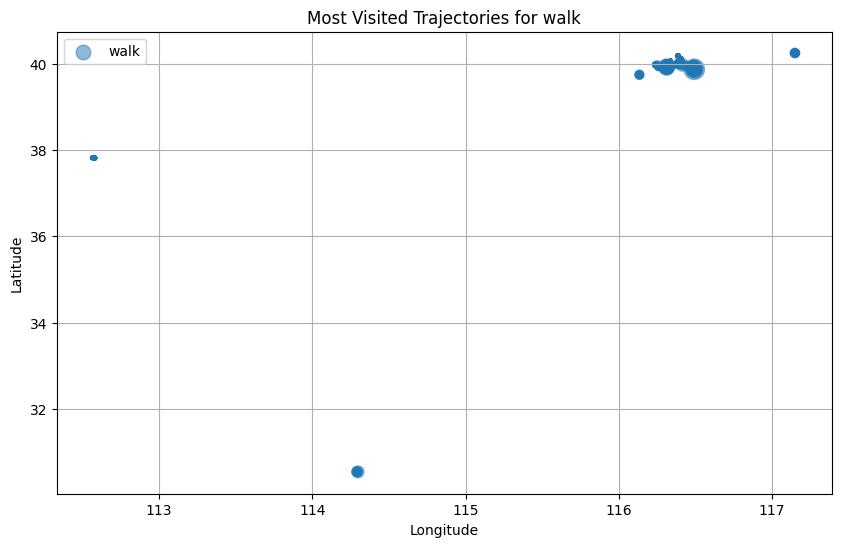

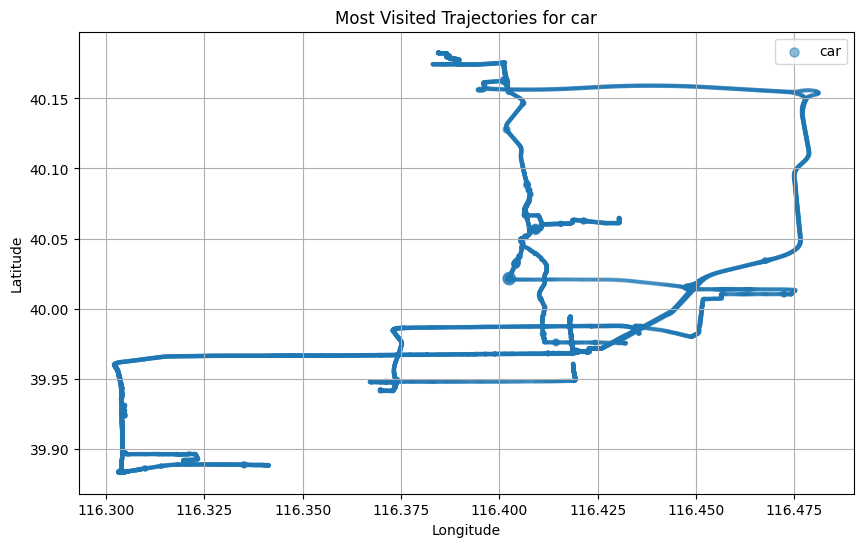

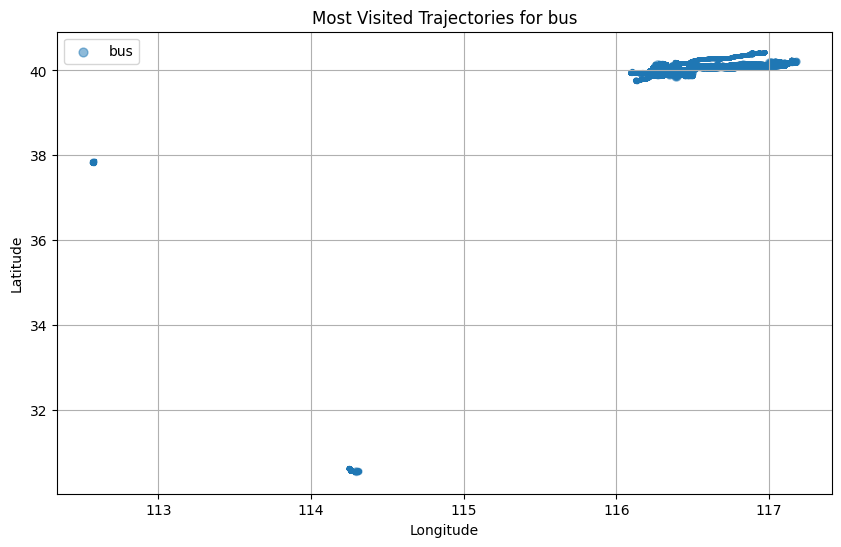

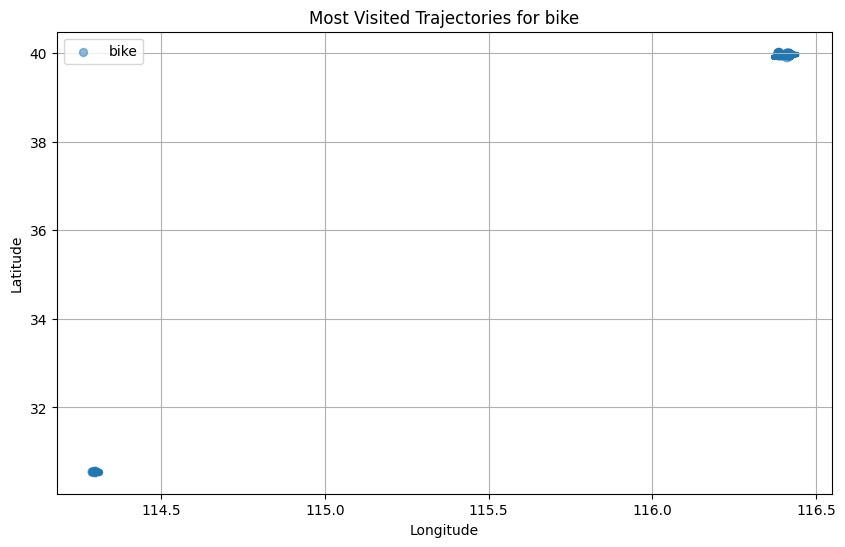

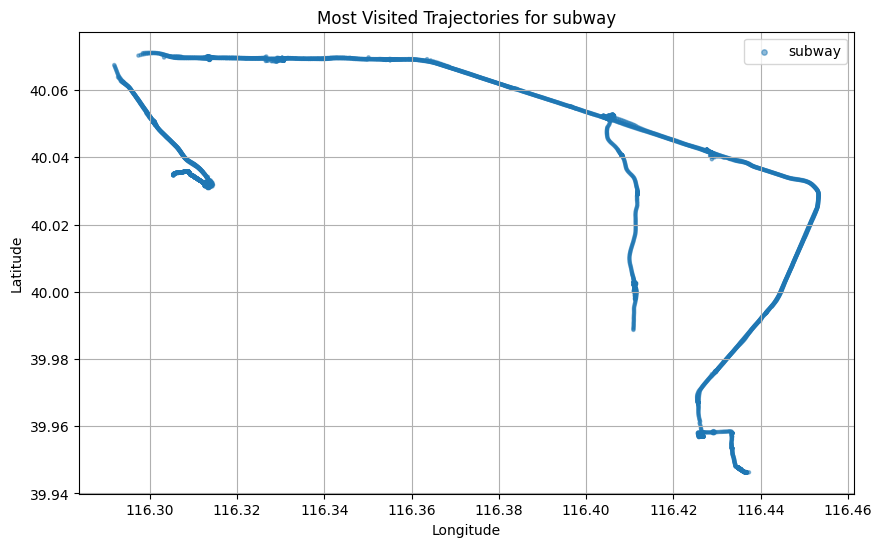

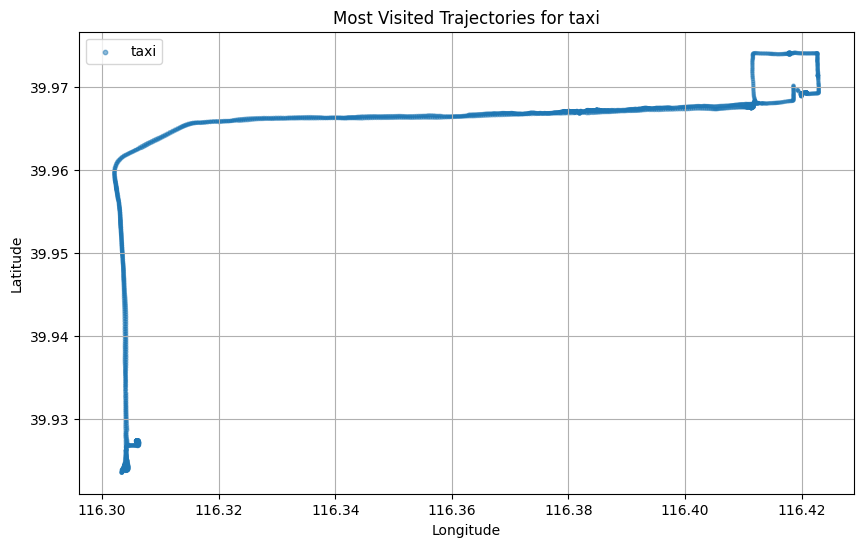

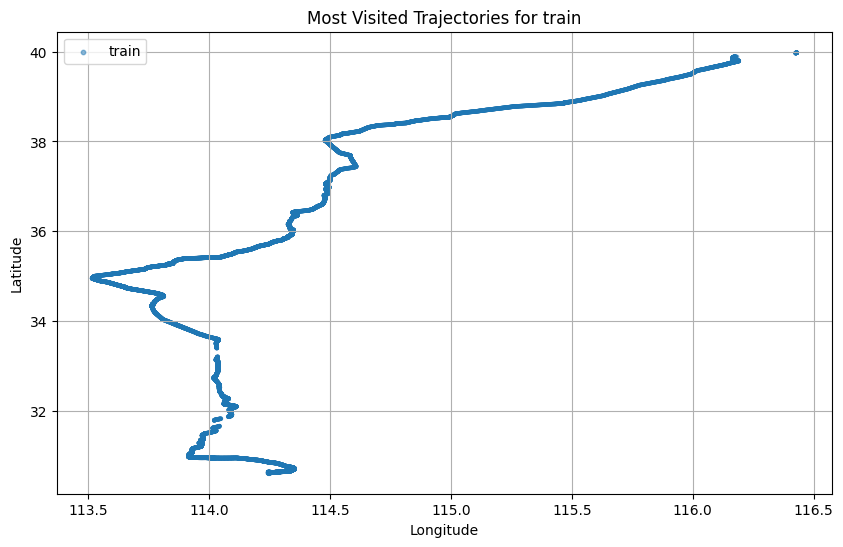

In [52]:
# Calculate the most visited trajectories through days by transport mode
def compute_most_visited_trajectories(df):
    # Group by user, transport mode, and trajectory
    grouped = df.groupby(['uid', 'label', 'lat', 'lon']).size().reset_index(name='count')
    # Sort by count to find the most visited trajectories
    most_visited = grouped.sort_values(by='count', ascending=False)
    return most_visited
# Compute the most visited trajectories
most_visited_trajectories = compute_most_visited_trajectories(user_data)
# Display the most visited trajectories by transport mode
print("\nMost visited trajectories by transport mode:")
display(most_visited_trajectories)
# Plot the most visited trajectories for each transport mode
for label in most_visited_trajectories['label'].unique():
    subset = most_visited_trajectories[most_visited_trajectories['label'] == label]
    plt.figure(figsize=(10, 6))
    plt.scatter(subset['lon'], subset['lat'], s=subset['count']*10, alpha=0.5, label=label)
    plt.title(f'Most Visited Trajectories for {label}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.legend()
    plt.grid(True)
    plt.show()
